# Weekly correlations: research report

**DSC–AC research series · fourteen market variables, 2003–2026**

This notebook rebuilds the weekly correlation report from outputs the MATLAB pipeline has **already saved**. It never runs MATLAB or the sampler. It covers three steps of the original pipeline that could not run on this machine:

| Original step | Why it did not run | Replaced here by |
|---|---|---|
| Stationarity and serial-dependence tests in `toolbox/analyze_weekly_panel.m` (`adftest`, `kpsstest`, `lbqtest`, `archtest`) | Needs the MATLAB Econometrics Toolbox | Section 6, computed with `statsmodels` |
| LaTeX report builder `scripts/build_publication.py` | Called as `python3` with Unix quoting; needed the stationarity CSVs | Sections 2–5 and 7–12 |
| Export check `tests/verify_exports.py` | Part of the Python tooling | Section 11 |

**Reading guide.** The rolling correlations are empirical estimates. The saved MATLAB run supplies the Bayesian draws and the computational measurements. Unless the run diagnostics establish otherwise, its draws are preliminary. Full-sample smoothing and empirical-Bayes calibration use information from later weeks, so a smoothed value for a historical week is not what was knowable at that time.

**How to run.** Open the notebook with the `env_research` kernel (Python 3.10 with numpy, pandas, matplotlib, scipy, statsmodels and h5py) and choose *Run All*. Section 1.1 selects the data folder and sampler run; by default it uses the most recent run.

## Contents
1. Setup
2. Inputs and consistency checks
3. Data and weekly alignment
4. Descriptive return results
5. Rolling correlations
6. Stationarity and serial dependence
7. Joint Bayesian correlation model
8. Sampler run
9. Run diagnostics
10. Bayesian correlation paths
11. Independent verification of the MATLAB exports
12. Summary of findings

Appendices: A. all rolling-correlation paths · B. all Bayesian correlation paths · C. exported files and provenance

## 1. Setup
### 1.1 Configuration
Edit `RUN_NAME` to report a specific sampler run; `None` picks the newest run folder that has posterior bands.

In [1]:
from pathlib import Path

# Repository root: the folder that contains run_weekly_model_report.m.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_weekly_model_report.m").is_file())
RESULTS_DIR = ROOT / "outputs" / "weekly_research"   # cfg.output_root of the MATLAB run
DATA_DIR = RESULTS_DIR / "data"

RUN_NAME = None          # e.g. "20260929-160220-697-chain1-w10-r10-thin1"; None = newest complete run
SAVE_OUTPUTS = True      # write tables and figures under outputs/weekly_research/notebook_report/<run>
STRICT_CHECKS = True     # stop at the first section whose consistency checks fail


def latest_run(results_dir):
    runs = [p for p in (results_dir / "runs").iterdir()
            if (p / "pilot_summary.json").is_file() and (p / "posterior_correlation_bands.mat").is_file()]
    if not runs:
        raise FileNotFoundError(f"No sampler run with posterior bands under {results_dir / 'runs'}")
    return max(runs, key=lambda p: p.name)   # run folders start with a sortable timestamp


RUN_DIR = RESULTS_DIR / "runs" / RUN_NAME if RUN_NAME else latest_run(RESULTS_DIR)
OUT_DIR = RESULTS_DIR / "notebook_report" / RUN_DIR.name
print(f"Repository : {ROOT}\nData       : {DATA_DIR}\nSampler run: {RUN_DIR.name}\nOutputs    : {OUT_DIR if SAVE_OUTPUTS else 'not saved'}")

Repository : c:\Users\Jules.Viard\Documents\GitHub\DSC-AC-model
Data       : c:\Users\Jules.Viard\Documents\GitHub\DSC-AC-model\outputs\weekly_research\data
Sampler run: 20260929-183839-212-chain1-w10-r100-thin1
Outputs    : c:\Users\Jules.Viard\Documents\GitHub\DSC-AC-model\outputs\weekly_research\notebook_report\20260929-183839-212-chain1-w10-r100-thin1


### 1.2 Libraries and plotting style

In [2]:
import hashlib
import json
import sys
import warnings
from datetime import datetime, timezone

import h5py
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import statsmodels
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline

NAVY, TEAL, GREY = "#17324D", "#148C8A", "#A9B3BF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.labelcolor": NAVY, "text.color": NAVY, "axes.edgecolor": GREY,
                     "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
pd.set_option("styler.format.escape", "html")   # table text such as "< 1.01" must not be read as HTML
print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"statsmodels {statsmodels.__version__} | scipy {scipy.__version__} | h5py {h5py.__version__}")

Python 3.10.19 | numpy 1.26.4 | pandas 2.2.3 | statsmodels 0.14.5 | scipy 1.15.3 | h5py 3.16.0


### 1.3 Helper functions
`check` records each consistency check; `check_report` shows a section's checks and, when `STRICT_CHECKS` is on, stops the notebook if any failed.

In [3]:
def short(ticker):
    return str(ticker).removesuffix(" Index")


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def show(text):
    display(Markdown(text))


def as_list(value):
    # MATLAB's jsonencode writes one-element arrays as scalars.
    return value if isinstance(value, list) else [value]


def ymd(stamp):
    return pd.Timestamp(stamp).strftime("%Y-%m-%d")


def fmt_p(p, lower, upper):
    """Format a p-value with the bounds of MATLAB's tabulated distributions."""
    if p <= lower:
        return f"≤ {lower:g}"
    if p >= upper:
        return f"≥ {upper:g}"
    return f"{p:.3f}"


def save_figure(fig, name):
    if SAVE_OUTPUTS:
        (OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
        fig.savefig(OUT_DIR / "figures" / name)


def save_table(frame, name, index=False):
    if SAVE_OUTPUTS:
        (OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
        frame.to_csv(OUT_DIR / "tables" / name, index=index)


CHECKS = []


def check(section, description, passed, detail=""):
    """passed=None records a skipped check."""
    result = "skipped" if passed is None else ("pass" if passed else "FAIL")
    CHECKS.append({"Section": section, "Check": description, "Result": result, "Detail": detail})


def check_report(section):
    table = pd.DataFrame([c for c in CHECKS if c["Section"] == section]).drop(columns="Section")
    display(table.style.hide(axis="index").map(
        lambda v: "color:#B00020;font-weight:bold" if v == "FAIL" else "", subset=["Result"]))
    failed = table[table.Result.eq("FAIL")]
    if len(failed) and STRICT_CHECKS:
        raise AssertionError(f"{len(failed)} {section} check(s) failed: " + "; ".join(failed.Check))

## 2. Inputs and consistency checks
This section loads the saved MATLAB outputs. It then repeats the report builder's consistency checks before anything is reported.

### 2.1 Saved outputs

In [4]:
summary = read_json(DATA_DIR / "data_summary.json")
returns = pd.read_csv(DATA_DIR / "weekly_returns.csv", parse_dates=["Date"]).set_index("Date")
levels = pd.read_csv(DATA_DIR / "weekly_levels.csv", parse_dates=["Date"]).set_index("Date")
quality = pd.read_csv(DATA_DIR / "weekly_quality.csv", parse_dates=["LevelDate", "SourceDate"])
return_quality = pd.read_csv(DATA_DIR / "weekly_return_quality.csv", parse_dates=["Date"])
series_summary = pd.read_csv(DATA_DIR / "series_summary.csv")
annual = pd.read_csv(DATA_DIR / "raw_annual_coverage.csv")
full = pd.read_csv(DATA_DIR / "full_sample_correlations.csv").sort_values("PairIndex").reset_index(drop=True)
rolling = pd.read_csv(DATA_DIR / "rolling_correlations.csv", parse_dates=["Date"])
changes = pd.read_csv(DATA_DIR / "correlation_changes.csv")

pilot = read_json(RUN_DIR / "pilot_summary.json")
run_manifest = read_json(RUN_DIR / "run_manifest.json")
paths_manifest = read_json(RUN_DIR / "figures" / "bayes_correlation_paths_manifest.json")
convergence = read_json(RUN_DIR / "convergence_diagnostics.json")
inference_path = RUN_DIR / "inference_metadata.json"
inference = read_json(inference_path) if inference_path.is_file() else None
prior_path = RUN_DIR / "prior_summary.json" if (RUN_DIR / "prior_summary.json").is_file() else DATA_DIR / "prior_summary.json"
prior = read_json(prior_path)

tickers = list(returns.columns)
labels = [short(t) for t in tickers]
m = len(tickers)
q = m * (m - 1) // 2
dates = returns.index
first, last = ymd(dates[0]), ymd(dates[-1])
excluded = int(pilot.get("excluded_initial_weeks", 0))

inventory = pd.DataFrame([
    ("data/weekly_returns.csv", f"{len(returns):,} weeks × {m} series"),
    ("data/weekly_levels.csv", f"{len(levels):,} Friday levels"),
    ("data/weekly_quality.csv", f"{len(quality):,} level cells"),
    ("data/full_sample_correlations.csv", f"{len(full)} pairs"),
    ("data/rolling_correlations.csv", f"{len(rolling):,} rows"),
    ("data/correlation_changes.csv", f"{len(changes)} rows"),
    (f"runs/{RUN_DIR.name}/pilot_summary.json", f"{pilot['status']}, {pilot['saved_draws']} retained draws"),
    (f"runs/{RUN_DIR.name}/posterior_correlation_bands.mat", "16/50/84 percentile paths"),
    (f"runs/{RUN_DIR.name}/convergence_diagnostics.json", convergence["status"]),
    (prior_path.relative_to(RESULTS_DIR).as_posix(), "calibrated priors"),
], columns=["File (under outputs/weekly_research)", "Contents"])
display(inventory.style.hide(axis="index"))

File (under outputs/weekly_research),Contents
data/weekly_returns.csv,"1,204 weeks × 14 series"
data/weekly_levels.csv,"1,205 Friday levels"
data/weekly_quality.csv,"16,870 level cells"
data/full_sample_correlations.csv,91 pairs
data/rolling_correlations.csv,"205,114 rows"
data/correlation_changes.csv,182 rows
runs/20260929-183839-212-chain1-w10-r100-thin1/pilot_summary.json,"iteration_limit, 100 retained draws"
runs/20260929-183839-212-chain1-w10-r100-thin1/posterior_correlation_bands.mat,16/50/84 percentile paths
runs/20260929-183839-212-chain1-w10-r100-thin1/convergence_diagnostics.json,insufficient_chains
runs/20260929-183839-212-chain1-w10-r100-thin1/prior_summary.json,calibrated priors


### 2.2 Weekly panel checks
These are the checks `build_publication.py` ran before writing the report.

In [5]:
S = "Panel"
check(S, "Series count matches data_summary.json", m == summary["n_series"], f"{m} series")
check(S, "Pair count equals m(m−1)/2", len(full) == q == summary["n_pairs"], f"{len(full)} pairs")
check(S, "USDCNH is excluded from the baseline", not any("USDCNH" in t for t in tickers))
check(S, "Baseline uses as-of closure marks", summary.get("closure_policy") == "asof", summary.get("closure_policy", ""))
check(S, "Return count and first/last dates match data_summary.json",
      len(returns) == summary["n_returns"] and first == summary["first_return"] and last == summary["last_return"],
      f"{len(returns):,} returns, {first} to {last}")
check(S, "Levels have one more date than returns, same series",
      len(levels) == summary["n_levels"] == len(returns) + 1 and list(levels.columns) == tickers,
      f"{len(levels):,} levels")
check(S, "Dates are unique, increasing Fridays",
      dates.is_unique and dates.is_monotonic_increasing and bool((dates.dayofweek == 4).all()))
check(S, "No missing weeks (7-day spacing)", bool((np.diff(dates.values) == np.timedelta64(7, "D")).all()))
reconstructed = 100 * np.diff(np.log(levels.to_numpy(float)), axis=0)
check(S, "Returns equal 100 × Δ log(levels)",
      np.allclose(reconstructed, returns.to_numpy(float), rtol=1e-9, atol=1e-10, equal_nan=True))
source_file = Path(summary.get("source_file", ""))
check(S, "Source file unchanged since the analysis (SHA-256)",
      sha256(source_file) == summary["source_hash"] if source_file.is_file() else None,
      source_file.name if source_file.is_file() else f"not found: {source_file}")
expected_pairs = [(tickers[i], tickers[j]) for j in range(m) for i in range(j + 1, m)]
check(S, "Pair order is MATLAB's column-major lower triangle",
      list(zip(full.TickerI, full.TickerJ)) == expected_pairs)
check(S, "Rolling output has unique Date/Window/Pair keys",
      not rolling.duplicated(["Date", "Window", "PairIndex"]).any())
check(S, "Rolling windows are exactly 52 and 104 weeks", set(rolling.Window.unique()) == {52, 104})
for w in (52, 104):
    sample = rolling[rolling.Window.eq(w)]
    counts = sample.groupby("Date").size()
    check(S, f"{w}-week output covers every end date × {q} pairs",
          counts.index.equals(dates[w - 1:]) and bool(counts.eq(q).all()), f"{counts.size:,} end dates")
    check(S, f"{w}-week sample counts lie in [0, {w}]", bool(sample.N.between(0, w).all()))
check_report(S)

Check,Result,Detail
Series count matches data_summary.json,pass,14 series
Pair count equals m(m−1)/2,pass,91 pairs
USDCNH is excluded from the baseline,pass,
Baseline uses as-of closure marks,pass,asof
Return count and first/last dates match data_summary.json,pass,"1,204 returns, 2003-08-15 to 2026-09-04"
"Levels have one more date than returns, same series",pass,"1,205 levels"
"Dates are unique, increasing Fridays",pass,
No missing weeks (7-day spacing),pass,
Returns equal 100 × Δ log(levels),pass,
Source file unchanged since the analysis (SHA-256),pass,yad_tickers_no_usdcnh_from_20030804.csv


### 2.3 Sampler-run provenance checks
These checks confirm that the saved run, its figures and its metadata describe the same data and the same sample.

In [6]:
S = "Run"
draws = int(paths_manifest["retained_draws"])
warmup = int(paths_manifest["warmup_removed"])
chains = int(pilot.get("num_chains", 1))
per_chain = as_list(pilot.get("saved_draws_per_chain", draws))
check(S, "Run and data share the same source hash", run_manifest.get("source_hash") == summary["source_hash"])
check(S, "At least two retained draws, matching the sampler summary",
      draws >= 2 and draws == int(pilot.get("saved_draws", -1)), f"{draws} draws")
check(S, "Warm-up count matches the sampler summary", warmup == int(pilot.get("burnin", warmup)),
      f"{warmup} warm-up iterations per chain")
check(S, "Per-chain draw counts add up to the pooled count", len(per_chain) == chains and sum(per_chain) == draws,
      f"{chains} chain(s): {per_chain}")
check(S, "Figures use the continuous [−1, 1] correlation scale",
      paths_manifest.get("color_scale") == [-1, 1] and "Continuous RdBu_r" in paths_manifest.get("color_rule", ""))
check(S, "Figure manifest belongs to this run",
      Path(paths_manifest.get("run_dir", RUN_DIR)).resolve() == RUN_DIR.resolve())
check(S, "Saved convergence JSON equals the sampler summary", convergence == pilot.get("convergence"))
check(S, "Convergence flag agrees with the diagnostic report",
      convergence["passed"] == bool(pilot.get("convergence_established", False)), convergence["status"])
check(S, "Modeled weeks = all weeks − calibration weeks", pilot.get("T") == summary["n_returns"] - excluded,
      f"T = {pilot.get('T')}, calibration weeks = {excluded}")
check(S, "Model sample starts right after the calibration block",
      pilot.get("first_date") == ymd(dates[excluded]) and pilot.get("last_date") == last and
      (not excluded or (pilot.get("calibration_start") == first and pilot.get("calibration_end") == ymd(dates[excluded - 1]))),
      f"{pilot.get('first_date')} to {pilot.get('last_date')}")
check(S, "Series and pair counts match the panel", pilot.get("m") == m and pilot.get("pairs") == q)
if inference is not None:
    required = {"inference_mode", "parameter_file", "parameters_estimated_at", "parameter_estimation_start",
                "parameter_estimation_end", "parameter_estimation_draws", "parameter_estimation_run",
                "smoothing_end", "parameter_uncertainty_in_bands", "parameter_smoothing"}
    check(S, "Inference metadata has all provenance fields", required.issubset(inference))
    check(S, "Inference metadata is identical in the run and figure manifests",
          inference == paths_manifest.get("inference") == run_manifest.get("inference"))
    mode, smoothing = inference["inference_mode"], inference["parameter_smoothing"]
    check(S, "Band-uncertainty label agrees with the inference mode",
          inference["parameter_uncertainty_in_bands"] == (mode == "parameter_estimation" or smoothing == "draws"),
          f"{mode}, parameter smoothing = {smoothing}")
    check(S, "Estimation and smoothing dates are consistent",
          inference["parameter_estimation_start"] == ymd(dates[excluded]) and inference["smoothing_end"] == last and
          inference["parameter_estimation_start"] <= inference["parameter_estimation_end"] <= inference["smoothing_end"],
          f"estimation {inference['parameter_estimation_start']} to {inference['parameter_estimation_end']}")
    check(S, "State diagnostics in the metadata equal the run's diagnostics", inference.get("state_convergence") == convergence)
check_report(S)

Check,Result,Detail
Run and data share the same source hash,pass,
"At least two retained draws, matching the sampler summary",pass,100 draws
Warm-up count matches the sampler summary,pass,10 warm-up iterations per chain
Per-chain draw counts add up to the pooled count,pass,1 chain(s): [100]
"Figures use the continuous [−1, 1] correlation scale",pass,
Figure manifest belongs to this run,pass,
Saved convergence JSON equals the sampler summary,pass,
Convergence flag agrees with the diagnostic report,pass,insufficient_chains
Modeled weeks = all weeks − calibration weeks,pass,"T = 1100, calibration weeks = 104"
Model sample starts right after the calibration block,pass,2005-08-12 to 2026-09-04


## 3. Data and weekly alignment
### 3.1 Weekly as-of construction
The raw file contains daily levels, not returns. Each Friday row uses every series' last available level on or before that Friday:

$$
L_{jt}=P_j(s_{jt}),\qquad s_{jt}=\max\{s\le f_t : P_j(s)\ \text{is observed}\},\qquad
y_{jt}=100\left[\log L_{jt}-\log L_{j,t-1}\right].
$$

Here $f_t$ is the Friday date. A market holiday in one country therefore does not remove the whole week for every market. *Endpoint age* is how old the value is when placed in the Friday row: a Friday close has age 0, a Thursday close age 1, a Tuesday close age 3.

In [7]:
first_level, last_level = summary["first_level"], summary["last_level"]
next_friday = ymd(pd.Timestamp(last_level) + pd.Timedelta(days=7))
closure_cells = quality[quality.ClosureLevel.astype(bool)]
closure_text = "; ".join(
    f"{short(r.Ticker)} on {ymd(r.LevelDate)} uses the level from {ymd(r.SourceDate)} ({r.AgeDays} days old)"
    for r in closure_cells.itertuples())
routine_max = int(quality.loc[~quality.ClosureLevel.astype(bool), "AgeDays"].max())
show(f"""
The first completed Friday level is **{first_level}**, so the first return runs to **{first}**.
The last complete week ends **{last_level}**; the {summary['excluded_final_raw_rows']} raw rows after it belong to the
incomplete week ending {next_friday} and are excluded. The panel has **{summary['n_levels']:,} level dates** and
**{summary['n_returns']:,} return dates**.

Routine cases use a value at most **{routine_max} calendar days** old. The flagged exception{'s are' if len(closure_cells) != 1 else ' is'}: {closure_text or 'none'}.
For NKYTR, Japanese markets were closed for the extended 2019 holiday around the imperial succession
(Japan Exchange Group, *Ten Consecutive Non-business Days in 2019*). The affected returns are flagged so they can be checked separately.
""")


The first completed Friday level is **2003-08-08**, so the first return runs to **2003-08-15**.
The last complete week ends **2026-09-04**; the 4 raw rows after it belong to the
incomplete week ending 2026-09-11 and are excluded. The panel has **1,205 level dates** and
**1,204 return dates**.

Routine cases use a value at most **4 calendar days** old. The flagged exception is: NKYTR on 2019-05-03 uses the level from 2019-04-26 (7 days old).
For NKYTR, Japanese markets were closed for the extended 2019 holiday around the imperial succession
(Japan Exchange Group, *Ten Consecutive Non-business Days in 2019*). The affected returns are flagged so they can be checked separately.


### 3.2 Data quality

In [8]:
quality_rows = pd.DataFrame([
    ("Raw daily rows", f"{summary['raw_rows']:,}"),
    ("Raw daily missing cells", f"{summary['raw_missing_cells']:,} ({100 * summary['raw_missing_fraction']:.2f}%)"),
    ("Weekly values not from a Friday close", f"{summary['carried_endpoint_cells']:,} ({100 * summary['carried_endpoint_fraction']:.2f}%)"),
    ("Fridays with at least one non-Friday value", f"{summary['fridays_with_carry']:,}"),
    ("Oldest value used in a Friday row", f"{summary['max_age_days']} days"),
    ("Returns flagged around the 2019 NKYTR closure", str(summary["closure_return_cells"])),
    ("Return cells masked out of the model", str(summary["model_masked_return_cells"])),
], columns=["Quality measure", "Count / rate"])
display(quality_rows.style.hide(axis="index"))

coverage = series_summary.assign(Ticker=series_summary.Ticker.map(short))[
    ["Ticker", "Label", "N", "RawMissingCells", "RawMissingFraction", "CarriedEndpoints", "MaxAgeDays"]]
display(coverage.style.hide(axis="index").format({"RawMissingFraction": "{:.2%}"}))

Quality measure,Count / rate
Raw daily rows,"6,029"
Raw daily missing cells,"1,883 (2.23%)"
Weekly values not from a Friday close,343 (2.03%)
Fridays with at least one non-Friday value,102
Oldest value used in a Friday row,7 days
Returns flagged around the 2019 NKYTR closure,2
Return cells masked out of the model,0


Ticker,Label,N,RawMissingCells,RawMissingFraction,CarriedEndpoints,MaxAgeDays
AUDUSD,AUD/USD,1204,0,0.00%,0,0
BCOMCOT,Brent total return,1204,218,3.62%,47,2
BCOMGCTR,Gold total return,1204,215,3.57%,45,2
EURUSD,EUR/USD,1204,0,0.00%,0,0
GBPUSD,GBP/USD,1204,0,0.00%,0,0
I02981JP,Japan government bonds,1204,127,2.11%,13,3
LEATTREU,Euro-area Treasuries,1204,150,2.49%,29,2
LSG1TRGU,UK gilts,1204,150,2.49%,29,2
LUATTRUU,US Treasuries,1204,214,3.55%,32,1
NKYTR,Japan equities,1204,372,6.17%,50,7


### 3.3 Endpoint age

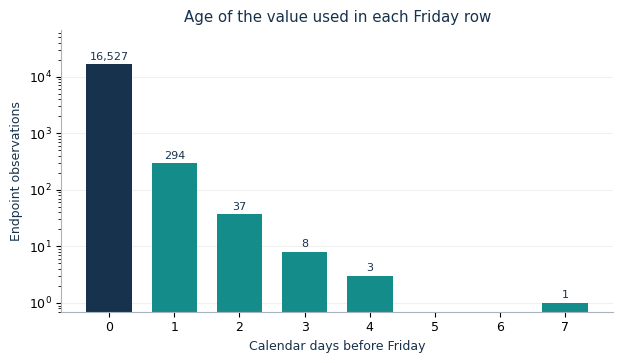

In [9]:
ages = quality.AgeDays.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.3, 3.7))
ax.bar(ages.index.astype(int), ages.values, color=[TEAL if x else NAVY for x in ages.index], width=.7)
ax.set(xlabel="Calendar days before Friday", ylabel="Endpoint observations", xticks=range(int(ages.index.max()) + 1),
       title="Age of the value used in each Friday row")
ax.set_yscale("log")
ax.set_ylim(.7, ages.max() * 4)
for x, count in ages.items():
    ax.text(x, count * 1.2, f"{int(count):,}", ha="center", fontsize=8)
ax.grid(axis="y", alpha=.18)
ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "endpoint_age.png")
plt.show()

### 3.4 Raw coverage by year
Share of missing daily cells per series and calendar year. The final year is partial.

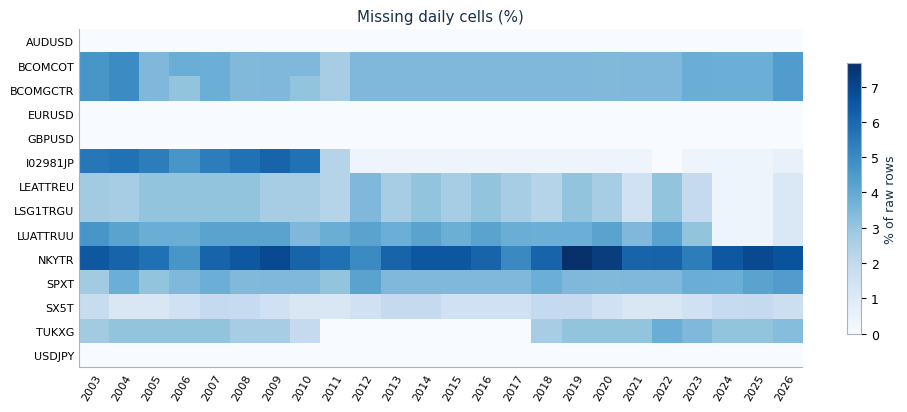

In [10]:
coverage_year = annual.assign(Ticker=annual.Ticker.map(short)).pivot(index="Ticker", columns="Year", values="MissingFraction")
coverage_year = coverage_year.loc[labels]
fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(100 * coverage_year.to_numpy(), cmap="Blues", aspect="auto", vmin=0)
ax.set(xticks=range(coverage_year.shape[1]), xticklabels=coverage_year.columns,
       yticks=range(m), yticklabels=coverage_year.index, title="Missing daily cells (%)")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right", rotation_mode="anchor")
ax.tick_params(length=0, labelsize=8)
fig.colorbar(im, ax=ax, shrink=.8, label="% of raw rows")
fig.tight_layout()
save_figure(fig, "raw_coverage_by_year.png")
plt.show()

## 4. Descriptive return results
All analyses use percentage weekly log returns. Standard deviations are weekly, with no annualization unless stated. Series names follow the supplied labels.

### 4.1 Summary statistics

In [11]:
descriptive = pd.DataFrame({
    "N": returns.count(), "Mean (%)": returns.mean(), "SD (%)": returns.std(),
    "1st pct.": returns.quantile(.01), "99th pct.": returns.quantile(.99)})
descriptive.index = pd.Index(labels, name="Ticker")
display(descriptive.style.format({"Mean (%)": "{:.3f}", "SD (%)": "{:.3f}", "1st pct.": "{:.2f}", "99th pct.": "{:.2f}"}))
save_table(descriptive, "descriptive_table.csv", index=True)

extended = series_summary.assign(Ticker=series_summary.Ticker.map(short)).set_index("Ticker")[
    ["Label", "AnnualizedMeanLogPct", "AnnualizedVolPct", "Skewness", "Kurtosis", "MinWeeklyPct", "MaxWeeklyPct", "ZeroReturns"]]
show("**Distribution shape and annualized moments** (annualized mean = 52 × weekly mean; volatility = √52 × weekly SD):")
display(extended.style.format({c: "{:.2f}" for c in extended.columns if c not in ("Label", "ZeroReturns")}))

,N,Mean (%),SD (%),1st pct.,99th pct.
Ticker,,,,,
AUDUSD,1204,0.008,1.695,-4.35,4.27
BCOMCOT,1204,0.127,4.666,-12.14,10.56
BCOMGCTR,1204,0.193,2.450,-7.12,6.18
EURUSD,1204,0.002,1.232,-3.37,2.97
GBPUSD,1204,-0.014,1.295,-3.69,2.82
I02981JP,1204,0.007,0.338,-0.94,0.85
LEATTREU,1204,0.049,0.629,-1.74,1.73
LSG1TRGU,1204,0.052,1.025,-2.72,2.53
LUATTRUU,1204,0.052,0.617,-1.51,1.58


**Distribution shape and annualized moments** (annualized mean = 52 × weekly mean; volatility = √52 × weekly SD):

,Label,AnnualizedMeanLogPct,AnnualizedVolPct,Skewness,Kurtosis,MinWeeklyPct,MaxWeeklyPct,ZeroReturns
Ticker,,,,,,,,
AUDUSD,AUD/USD,0.43,12.22,-1.35,16.94,-18.52,7.02,3
BCOMCOT,Brent total return,6.61,33.64,-0.42,6.67,-25.87,24.13,0
BCOMGCTR,Gold total return,10.05,17.67,-0.29,4.93,-10.13,12.34,0
EURUSD,EUR/USD,0.11,8.89,-0.23,4.83,-6.05,4.99,5
GBPUSD,GBP/USD,-0.74,9.34,-0.48,6.70,-8.35,6.90,3
I02981JP,Japan government bonds,0.35,2.44,-0.14,8.21,-2.05,2.53,0
LEATTREU,Euro-area Treasuries,2.53,4.54,-0.15,5.75,-2.84,2.97,0
LSG1TRGU,UK gilts,2.68,7.39,-0.14,5.79,-5.95,5.39,0
LUATTRUU,US Treasuries,2.68,4.45,-0.06,4.19,-2.39,2.77,0


### 4.2 Full-sample correlations
Pearson correlations of pairwise-available weekly returns over the whole sample. The baseline keeps the flagged as-of marks around the closure.

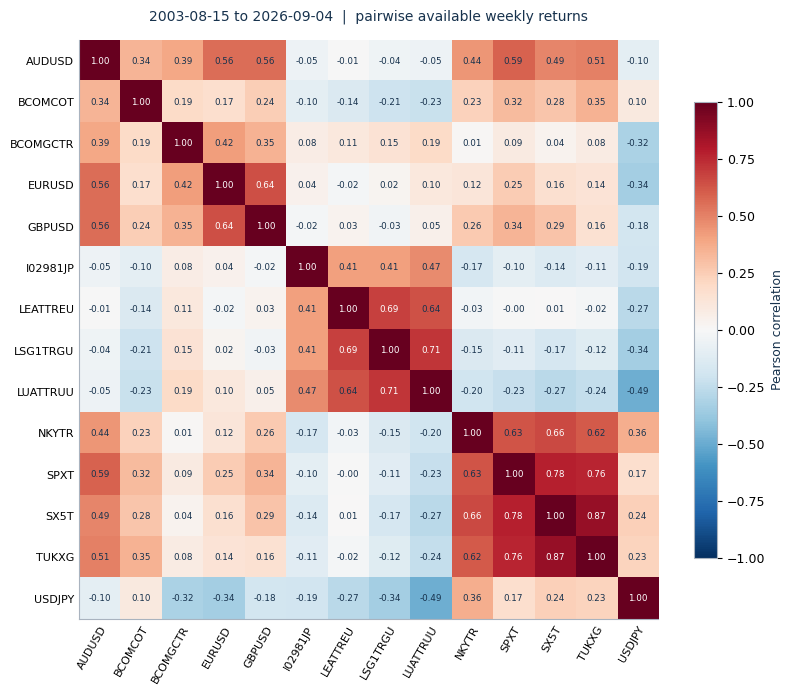

In [12]:
corr = np.eye(m)
index_of = {t: i for i, t in enumerate(tickers)}
for row in full.itertuples():
    i, j = index_of[row.TickerI], index_of[row.TickerJ]
    corr[i, j] = corr[j, i] = row.Correlation
fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set(xticks=np.arange(m), yticks=np.arange(m), xticklabels=labels, yticklabels=labels)
ax.tick_params(axis="both", length=0, labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right", rotation_mode="anchor")
for i in range(m):
    for j in range(m):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=6.3,
                color="white" if abs(corr[i, j]) > .64 else NAVY)
fig.colorbar(im, ax=ax, shrink=.75, label="Pearson correlation")
ax.set_title(f"{first} to {last}  |  pairwise available weekly returns", fontsize=10, pad=14)
fig.tight_layout()
save_figure(fig, "full_correlation.png")
plt.show()

### 4.3 Strongest pairs

In [13]:
pair_label = lambda a, b: f"{short(a)} / {short(b)}"
full["Pair"] = [pair_label(a, b) for a, b in zip(full.TickerI, full.TickerJ)]
top_pos = full.nlargest(5, "Correlation")[["Pair", "Correlation", "N"]]
top_neg = full.nsmallest(5, "Correlation")[["Pair", "Correlation", "N"]]
show("**Most positive**")
display(top_pos.style.hide(axis="index").format({"Correlation": "{:.2f}"}))
show("**Most negative**")
display(top_neg.style.hide(axis="index").format({"Correlation": "{:.2f}"}))
strong = full.iloc[np.abs(full.Correlation.to_numpy()).argmax()]

**Most positive**

Pair,Correlation,N
TUKXG / SX5T,0.87,1204
SX5T / SPXT,0.78,1204
TUKXG / SPXT,0.76,1204
LUATTRUU / LSG1TRGU,0.71,1204
LSG1TRGU / LEATTREU,0.69,1204


**Most negative**

Pair,Correlation,N
USDJPY / LUATTRUU,-0.49,1204
USDJPY / LSG1TRGU,-0.34,1204
USDJPY / EURUSD,-0.34,1204
USDJPY / BCOMGCTR,-0.32,1204
USDJPY / LEATTREU,-0.27,1204


## 5. Rolling correlations
Trailing 52- and 104-week windows. A window counts only if it is complete for that pair; incomplete windows are left empty, never shortened. No window uses future observations.

### 5.1 Reference pairs

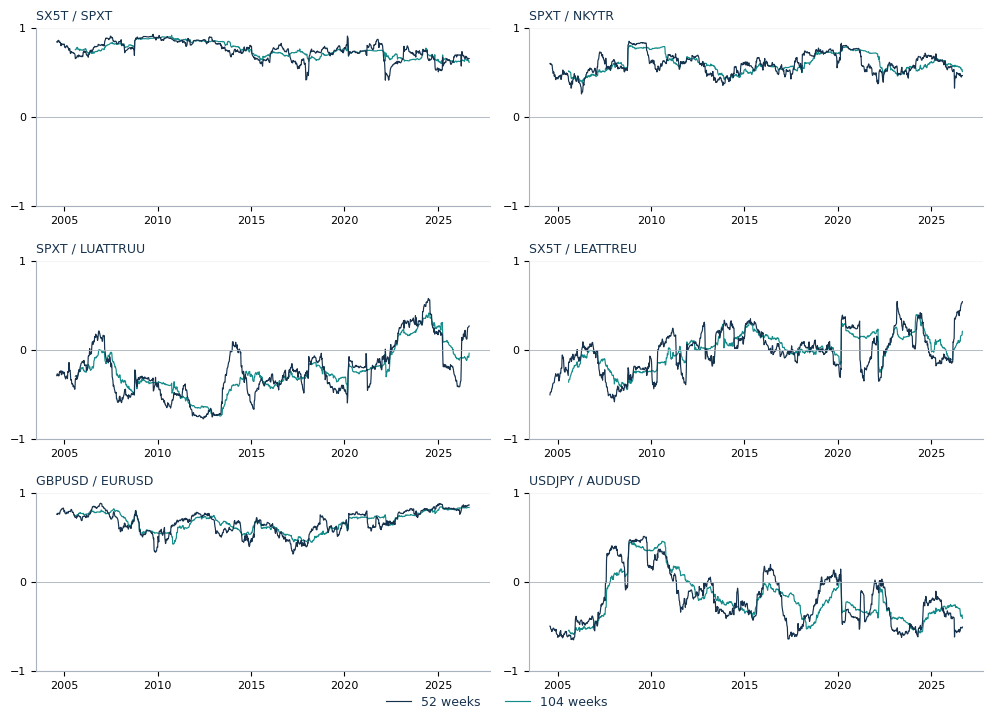

In [14]:
def find_pair(a, b):
    chosen = full[(full.TickerI.map(short).eq(a) & full.TickerJ.map(short).eq(b)) |
                  (full.TickerI.map(short).eq(b) & full.TickerJ.map(short).eq(a))]
    if len(chosen) != 1:
        raise ValueError(f"No unique requested pair: {a}/{b}")
    return chosen.iloc[0]


def rolling_plot(rows, filename=None, ncols=2, height=2.4, numbered=False, width=10, title=None):
    nrows = (len(rows) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, height * nrows), squeeze=False)
    for ax, row in zip(axes.flat, rows):
        data = rolling[rolling.PairIndex.eq(row.PairIndex)]
        for window, color in [(104, TEAL), (52, NAVY)]:
            d = data[data.Window.eq(window)].sort_values("Date")
            ax.plot(d.Date, d.Correlation, color=color, lw=.85, label=f"{window} weeks")
        name = pair_label(row.TickerI, row.TickerJ)
        ax.set_title((f"{int(row.PairIndex):02d}. " if numbered else "") + name, fontsize=9, loc="left")
        ax.set(ylim=(-1, 1), yticks=[-1, 0, 1])
        ax.axhline(0, color=GREY, lw=.6)
        ax.grid(axis="y", alpha=.12)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.tick_params(labelsize=8)
    for ax in list(axes.flat)[len(rows):]:
        ax.axis("off")
    handles, labs = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labs[::-1], loc="lower center", ncol=2, frameon=False, fontsize=9)
    if title:
        fig.suptitle(title, fontsize=11, x=.01, ha="left")
    fig.tight_layout(rect=[0, .05 / nrows, 1, 1], h_pad=1.3)
    if filename:
        save_figure(fig, filename)
    plt.show()


reference_pairs = [find_pair("SPXT", "SX5T"), find_pair("SPXT", "NKYTR"), find_pair("SPXT", "LUATTRUU"),
                   find_pair("SX5T", "LEATTREU"), find_pair("EURUSD", "GBPUSD"), find_pair("AUDUSD", "USDJPY")]
rolling_plot(reference_pairs, "selected_pairs.png")

### 5.2 Latest values and ranges

In [15]:
r52 = rolling[rolling.Window.eq(52) & rolling.Correlation.notna()]
latest52 = r52[r52.Date.eq(r52.Date.max())].set_index("PairIndex")
ranges = r52.groupby("PairIndex").Correlation.agg(["min", "max"])
ranges["range"] = ranges["max"] - ranges["min"]
widest = full[full.PairIndex.eq(int(ranges["range"].idxmax()))].iloc[0]


def latest(window, pair_index):
    d = rolling[rolling.Window.eq(window) & rolling.PairIndex.eq(pair_index)].sort_values("Date")
    return d.Correlation.iloc[-1]


window_table = pd.DataFrame([{
    "Pair": pair_label(r.TickerI, r.TickerJ), "Full sample": r.Correlation,
    "Latest 52": latest52.loc[r.PairIndex, "Correlation"], "Latest 104": latest(104, r.PairIndex),
    "52 min": ranges.loc[r.PairIndex, "min"], "52 max": ranges.loc[r.PairIndex, "max"]} for r in reference_pairs])
display(window_table.style.hide(axis="index").format(precision=2))
save_table(window_table, "rolling_findings.csv")
show(f"Latest estimates end {last}. Minimum and maximum refer to the entire available 52-week path.")

Pair,Full sample,Latest 52,Latest 104,52 min,52 max
SX5T / SPXT,0.78,0.66,0.62,0.42,0.93
SPXT / NKYTR,0.63,0.47,0.51,0.26,0.85
SPXT / LUATTRUU,-0.23,0.26,-0.04,-0.78,0.57
SX5T / LEATTREU,0.01,0.54,0.20,-0.59,0.54
GBPUSD / EURUSD,0.64,0.86,0.84,0.31,0.88
USDJPY / AUDUSD,-0.10,-0.51,-0.41,-0.65,0.51


Latest estimates end 2026-09-04. Minimum and maximum refer to the entire available 52-week path.

### 5.3 Largest changes
`correlation_changes.csv` compares each pair's first and last complete window. Weekly steps only compare consecutive calendar weeks.

In [16]:
net104 = changes[changes.Window.eq(104) & changes.NetChange.notna()].copy()
net104["Pair"] = [pair_label(a, b) for a, b in zip(net104.TickerI, net104.TickerJ)]
net104 = net104.reindex(net104.NetChange.abs().sort_values(ascending=False).index).head(10)
show("**Largest 104-week net changes** (first to last complete window):")
display(net104[["Pair", "FirstCorrelation", "LastCorrelation", "NetChange", "MinCorrelation", "MinDate",
                "MaxCorrelation", "MaxDate"]].style.hide(axis="index").format(precision=2))

step = changes.groupby("Window")[["TickerI", "TickerJ", "CrossesZero", "MaxAbsStepChange", "LargestStepDate"]].apply(lambda g: pd.Series({
    "Pairs whose path crosses zero": int(g.CrossesZero.sum()),
    "Largest weekly step": g.MaxAbsStepChange.max(),
    "Pair with largest step": pair_label(*g.loc[g.MaxAbsStepChange.idxmax(), ["TickerI", "TickerJ"]]),
    "Step date": g.loc[g.MaxAbsStepChange.idxmax(), "LargestStepDate"]}))
display(step.style.format({"Largest weekly step": "{:.3f}"}))

**Largest 104-week net changes** (first to last complete window):

Pair,FirstCorrelation,LastCorrelation,NetChange,MinCorrelation,MinDate,MaxCorrelation,MaxDate
TUKXG / LSG1TRGU,-0.34,0.42,0.76,-0.64,2013-01-25,0.43,2025-03-28
TUKXG / LEATTREU,-0.40,0.34,0.74,-0.42,2008-05-09,0.34,2026-09-04
TUKXG / LUATTRUU,-0.47,0.21,0.68,-0.66,2013-02-15,0.27,2025-03-28
SX5T / LEATTREU,-0.37,0.20,0.57,-0.45,2008-09-26,0.39,2024-03-29
SX5T / LSG1TRGU,-0.32,0.25,0.57,-0.71,2012-12-21,0.38,2024-03-15
SPXT / LEATTREU,-0.33,0.23,0.56,-0.51,2008-10-03,0.41,2024-05-24
LSG1TRGU / BCOMCOT,0.09,-0.40,-0.49,-0.49,2010-10-15,0.10,2005-09-30
LEATTREU / BCOMCOT,0.06,-0.43,-0.49,-0.44,2026-08-28,0.16,2022-03-04
SX5T / LUATTRUU,-0.39,0.09,0.48,-0.73,2013-05-17,0.35,2024-03-15
USDJPY / BCOMGCTR,-0.56,-0.14,0.42,-0.73,2018-01-26,0.08,2011-06-03


,Pairs whose path crosses zero,Largest weekly step,Pair with largest step,Step date
Window,,,,
52,76,0.627,TUKXG / BCOMCOT,2022-03-04
104,71,0.403,SX5T / LUATTRUU,2020-03-13


## 6. Stationarity and serial dependence
This section replaces `stationarityTables` in `toolbox/analyze_weekly_panel.m`, which needed the MATLAB Econometrics Toolbox. It uses the same data (complete as-of marks, including the flagged closure) and the same specifications:

| Test | Null hypothesis | Specification |
|---|---|---|
| Augmented Dickey–Fuller (ADF) | unit root | constant (`ARD`); log levels also with constant and trend (`TS`); lags 0–13 chosen by BIC on one common regression sample |
| KPSS | level (or trend) stationarity | Newey–West (Bartlett) bandwidths 4, 13 and 26 weeks |
| Ljung–Box | no autocorrelation up to lag 13 | returns, and squared demeaned returns |
| Engle ARCH LM | no ARCH effects up to lag 13 | demeaned returns |

**Differences from MATLAB.** Statistics, lag selection and the KPSS, Ljung–Box and ARCH p-values follow the same formulas. ADF p-values come from MacKinnon's response surfaces (`statsmodels`) instead of MATLAB's tables, so they can differ slightly. For comparability, p-values beyond MATLAB's table limits are shown as bounds: ADF [0.001, 0.999], KPSS [0.01, 0.10]. Decisions are nominal 5% tests with no correction for testing many series. These tests concern the mean and unit-root specification; they do not establish constant variance or stable model parameters.

### 6.1 Test implementation

In [17]:
MAX_LAG, KPSS_BANDWIDTHS, DEPENDENCE_LAGS, ALPHA = 13, (4, 13, 26), 13, 0.05
ADF_BOUNDS, KPSS_BOUNDS = (0.001, 0.999), (0.01, 0.10)
ADF_REGRESSION = {"ARD": "c", "TS": "ct"}   # MATLAB adftest 'Model' -> statsmodels 'regression'


def bound_label(p, lower, upper):
    # Same labels as the MATLAB export, so build_publication.py can read these CSVs.
    return f"<={lower:g}" if p <= lower else (f">={upper:g}" if p >= upper else "interpolated")


def adf_candidates_for(y, model):
    """ADF for lags 0..MAX_LAG. Each lag drops the first MAX_LAG−lag points so all regressions share one sample."""
    rows = []
    for lag in range(MAX_LAG + 1):
        common = y[MAX_LAG - lag:]
        stat, p, crit, store = adfuller(common, maxlag=lag, regression=ADF_REGRESSION[model],
                                        autolag=None, regresults=True)
        rows.append({"Lags": lag, "Statistic": stat, "PValue": p, "BIC": store.resols.bic,
                     "N": int(store.resols.nobs), "Critical5pct": crit["5%"], "ValidStatistic": bool(np.isfinite(stat))})
    candidates = pd.DataFrame(rows)
    if candidates.N.nunique() != 1:
        raise ValueError("ADF lag candidates use different regression samples")
    candidates["Selected"] = candidates.index == candidates.BIC.idxmin()
    return candidates


def kpss_for(y, trend, bandwidth):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)   # p-value at a table bound
        stat, p, _, crit = kpss(y, regression="ct" if trend else "c", nlags=bandwidth)
    return stat, p


def dependence_for(y):
    residual = y - y.mean()
    statistics = {
        "LjungBoxReturns": acorr_ljungbox(y, lags=[DEPENDENCE_LAGS]).lb_stat.iloc[0],
        "LjungBoxSquaredReturns": acorr_ljungbox(residual ** 2, lags=[DEPENDENCE_LAGS]).lb_stat.iloc[0],
        "ARCH": het_arch(residual, nlags=DEPENDENCE_LAGS)[0]}
    # Upper-tail chi-square directly, as in the MATLAB code (1 − CDF loses tiny p-values).
    return {name: (s, stats.chi2.sf(s, DEPENDENCE_LAGS)) for name, s in statistics.items()}

### 6.2 Run the tests
The three output tables keep the MATLAB schema (`stationarity.csv`, `adf_candidates.csv`, `diagnostics.csv`).

In [18]:
SPECS = [("log_level", "ARD", False), ("log_level", "TS", True), ("weekly_log_return_pct", "ARD", False)]
log_levels = np.log(levels)
stationarity_rows, candidate_rows, diagnostic_rows = [], [], []
for ticker in tickers:
    for transform, model, trend in SPECS:
        series = log_levels[ticker] if transform == "log_level" else returns[ticker]
        y = series.to_numpy(float)
        if not np.isfinite(y).all():
            raise ValueError(f"{ticker}/{transform} has missing values; the tests need a complete series")
        candidates = adf_candidates_for(y, model)
        chosen = candidates[candidates.Selected].iloc[0]
        if not chosen.ValidStatistic:
            raise ValueError(f"BIC-selected ADF statistic is invalid for {ticker}/{transform}/{model}")
        for c in candidates.itertuples():
            candidate_rows.append({"Ticker": ticker, "Transform": transform, "Model": model, "Lags": c.Lags,
                                   "BIC": c.BIC, "N": c.N, "Selected": c.Selected, "ValidStatistic": c.ValidStatistic,
                                   "Statistic": c.Statistic, "PValue": c.PValue,
                                   "FirstDependentDate": ymd(series.index[MAX_LAG + 1]), "LastDependentDate": ymd(series.index[-1])})
        stationarity_rows.append({"Ticker": ticker, "Transform": transform, "Test": "ADF", "Model": model,
                                  "Lags": int(chosen.Lags), "Statistic": chosen.Statistic, "PValue": chosen.PValue,
                                  "PValueBound": bound_label(chosen.PValue, *ADF_BOUNDS),
                                  "Reject5pct": bool(chosen.PValue < ALPHA), "N": int(chosen.N), "BIC": chosen.BIC})
        for bandwidth in KPSS_BANDWIDTHS:
            stat, p = kpss_for(y, trend, bandwidth)
            stationarity_rows.append({"Ticker": ticker, "Transform": transform, "Test": "KPSS",
                                      "Model": "trend" if trend else "level", "Lags": bandwidth, "Statistic": stat,
                                      "PValue": p, "PValueBound": bound_label(p, *KPSS_BOUNDS),
                                      "Reject5pct": bool(p < ALPHA), "N": len(y), "BIC": np.nan})
    for name, (stat, p) in dependence_for(returns[ticker].to_numpy(float)).items():
        diagnostic_rows.append({"Ticker": ticker, "Test": name, "Lags": DEPENDENCE_LAGS, "Statistic": stat, "PValue": p,
                                "PValueBound": "<1e-12" if p < 1e-12 else "numeric", "Reject5pct": bool(p < ALPHA),
                                "N": len(returns)})

stationarity = pd.DataFrame(stationarity_rows)
adf_candidates = pd.DataFrame(candidate_rows)
diagnostics = pd.DataFrame(diagnostic_rows)
for frame, name in [(stationarity, "stationarity.csv"), (adf_candidates, "adf_candidates.csv"), (diagnostics, "diagnostics.csv")]:
    save_table(frame, name)
print(f"{len(stationarity)} stationarity rows, {len(adf_candidates)} ADF lag candidates, {len(diagnostics)} dependence rows")

168 stationarity rows, 588 ADF lag candidates, 42 dependence rows


### 6.3 Weekly returns

In [19]:
is_return = stationarity.Transform.eq("weekly_log_return_pct")
adf = stationarity[is_return & stationarity.Test.eq("ADF")].set_index("Ticker")
kpss_r = stationarity[is_return & stationarity.Test.eq("KPSS")]
return_table = pd.DataFrame({
    "ADF lag": adf.Lags, "ADF stat.": adf.Statistic.round(3),
    "ADF p": [fmt_p(p, *ADF_BOUNDS) for p in adf.PValue],
    **{f"KPSS({b})": [fmt_p(p, *KPSS_BOUNDS) for p in kpss_r[kpss_r.Lags.eq(b)].set_index("Ticker").loc[adf.index, "PValue"]]
       for b in KPSS_BANDWIDTHS}})
return_table.index = return_table.index.map(short)
display(return_table)

adf_rejections = int(adf.Reject5pct.sum())
common_n = int(adf.N.iloc[0])
kpss_groups = {}
for b in KPSS_BANDWIDTHS:
    kb = kpss_r[kpss_r.Lags.eq(b)]
    names = ", ".join(short(t) for t in kb[kb.Reject5pct].Ticker) or "none"
    kpss_groups.setdefault(names, []).append(str(b))
kpss_text = " ".join(f"At bandwidth{'s' if len(bs) > 1 else ''} {', '.join(bs)}, KPSS rejects stationarity around a constant mean for: {names}."
                     for names, bs in kpss_groups.items())
show(f"""ADF null: a unit root. Lag selection uses a common {common_n:,}-observation regression sample.
**ADF rejects a unit root for {adf_rejections} of {len(adf)} return series at 5%.** The largest ADF p-value is
{fmt_p(adf.PValue.max(), *ADF_BOUNDS)}. {kpss_text}""")

,ADF lag,ADF stat.,ADF p,KPSS(4),KPSS(13),KPSS(26)
Ticker,,,,,,
AUDUSD,0,-36.245,≤ 0.001,≥ 0.1,≥ 0.1,≥ 0.1
BCOMCOT,0,-33.002,≤ 0.001,≥ 0.1,≥ 0.1,≥ 0.1
BCOMGCTR,0,-35.649,≤ 0.001,≥ 0.1,≥ 0.1,≥ 0.1
EURUSD,0,-34.942,≤ 0.001,≥ 0.1,≥ 0.1,≥ 0.1
GBPUSD,1,-26.761,≤ 0.001,≥ 0.1,≥ 0.1,≥ 0.1
I02981JP,0,-36.053,≤ 0.001,≤ 0.01,≤ 0.01,≤ 0.01
LEATTREU,0,-34.087,≤ 0.001,0.022,0.024,0.036
LSG1TRGU,0,-35.935,≤ 0.001,0.033,0.027,0.034
LUATTRUU,0,-36.459,≤ 0.001,0.092,≥ 0.1,≥ 0.1


ADF null: a unit root. Lag selection uses a common 1,190-observation regression sample.
**ADF rejects a unit root for 14 of 14 return series at 5%.** The largest ADF p-value is
≤ 0.001. At bandwidths 4, 13, 26, KPSS rejects stationarity around a constant mean for: I02981JP, LEATTREU, LSG1TRGU.

### 6.4 Weekly log levels

In [20]:
is_level = stationarity.Transform.eq("log_level")
level_adf = stationarity[is_level & stationarity.Test.eq("ADF")]
drift, trend_adf = (level_adf[level_adf.Model.eq(x)].set_index("Ticker") for x in ("ARD", "TS"))
level_kpss = stationarity[is_level & stationarity.Test.eq("KPSS") & stationarity.Model.eq("level")]
level_table = pd.DataFrame({
    "ADF const. p": [fmt_p(p, *ADF_BOUNDS) for p in drift.PValue],
    "ADF trend p": [fmt_p(p, *ADF_BOUNDS) for p in trend_adf.loc[drift.index, "PValue"]],
    **{f"KPSS({b})": [fmt_p(p, *KPSS_BOUNDS) for p in level_kpss[level_kpss.Lags.eq(b)].set_index("Ticker").loc[drift.index, "PValue"]]
       for b in KPSS_BANDWIDTHS}}, index=drift.index.map(short))
display(level_table)

level_groups = {}
for b in KPSS_BANDWIDTHS:
    kb = level_kpss[level_kpss.Lags.eq(b)]
    level_groups.setdefault((int(kb.Reject5pct.sum()), len(kb)), []).append(str(b))
level_kpss_text = " ".join(f"KPSS rejects constant-mean stationarity for {r} of {n} log-level series at bandwidth{'s' if len(bs) > 1 else ''} {', '.join(bs)}."
                           for (r, n), bs in level_groups.items())
trend_names = ", ".join(short(t) for t in trend_adf[trend_adf.Reject5pct].index) or "none"
show(f"""The constant-only ADF rejects a unit root for **{int(drift.Reject5pct.sum())} of {len(drift)}** log-level series.
{level_kpss_text} With a deterministic trend, ADF rejects for: {trend_names}. The broad evidence against stationarity therefore
concerns log levels, not returns. Failing to reject an ADF unit root does not by itself prove that a unit root exists.""")

,ADF const. p,ADF trend p,KPSS(4),KPSS(13),KPSS(26)
Ticker,,,,,
AUDUSD,0.271,0.248,≤ 0.01,≤ 0.01,≤ 0.01
BCOMCOT,0.444,0.767,≤ 0.01,≤ 0.01,0.049
BCOMGCTR,0.837,0.778,≤ 0.01,≤ 0.01,≤ 0.01
EURUSD,0.245,0.069,≤ 0.01,≤ 0.01,≤ 0.01
GBPUSD,0.542,0.133,≤ 0.01,≤ 0.01,≤ 0.01
I02981JP,0.401,≥ 0.999,≤ 0.01,≤ 0.01,≤ 0.01
LEATTREU,0.141,0.980,≤ 0.01,≤ 0.01,≤ 0.01
LSG1TRGU,0.209,0.973,≤ 0.01,≤ 0.01,≤ 0.01
LUATTRUU,0.207,0.850,≤ 0.01,≤ 0.01,≤ 0.01


The constant-only ADF rejects a unit root for **0 of 14** log-level series.
KPSS rejects constant-mean stationarity for 14 of 14 log-level series at bandwidths 4, 13, 26. With a deterministic trend, ADF rejects for: TUKXG. The broad evidence against stationarity therefore
concerns log levels, not returns. Failing to reject an ADF unit root does not by itself prove that a unit root exists.

### 6.5 Serial dependence and volatility clustering

In [21]:
dependence = diagnostics.pivot(index="Ticker", columns="Test", values="PValue")[["LjungBoxReturns", "LjungBoxSquaredReturns", "ARCH"]]
dependence.index = dependence.index.map(short)
display(dependence.style.format(lambda p: "< 1e-12" if p < 1e-12 else (f"{p:.1e}" if p < 1e-4 else f"{p:.4f}"))
        .map(lambda p: "font-weight:bold" if p < ALPHA else "")
        .set_caption(f"p-values, {DEPENDENCE_LAGS} weekly lags (bold: reject at 5%)"))
counts = diagnostics.groupby("Test").Reject5pct.agg(["sum", "count"])
raw_lb = diagnostics[diagnostics.Test.eq("LjungBoxReturns")]
rejected_raw = ", ".join(short(t) for t in raw_lb[raw_lb.Reject5pct].Ticker) or "none"
arch, squared = counts.loc["ARCH"], counts.loc["LjungBoxSquaredReturns"]
show(f"""
**Do earlier returns help explain this week's return?** The Ljung–Box test checks whether a series is correlated with its own
returns over the previous {DEPENDENCE_LAGS} weeks, roughly three months. It finds evidence of a relationship in
**{int(counts.loc['LjungBoxReturns', 'sum'])} of {len(raw_lb)} series**: {rejected_raw}. Past returns may carry some information about later
returns, but the test alone does not say how large the effect is, whether it reflects continuation or reversal, or whether it helps forecasting.

**Does the size of market moves vary in persistent spells?** The ARCH test and the Ljung–Box test on squared, demeaned returns look at the size
of moves regardless of direction. They find dependence in **{int(arch['sum'])} of {int(arch['count'])}** and
**{int(squared['sum'])} of {int(squared['count'])}** series, respectively. This is consistent with volatility clustering: turbulent weeks come in
spells, as do calm weeks. It supports letting the model's risk estimate change over time; it does not by itself show that correlations change.

**What this means for the model.** Volatility is allowed to vary. Whether a simple dependence on last week's return improves the mean equation remains
to be assessed. These checks describe the data before model fitting; after estimation they should be repeated on the model's innovations.
Dependence across weeks is not a unit root and does not call for differencing returns again.
""")

Test,LjungBoxReturns,LjungBoxSquaredReturns,ARCH
Ticker,,,
AUDUSD,0.0719,< 1e-12,< 1e-12
BCOMCOT,0.0058,< 1e-12,< 1e-12
BCOMGCTR,0.8634,< 1e-12,< 1e-12
EURUSD,0.0562,< 1e-12,< 1e-12
GBPUSD,0.0004,< 1e-12,< 1e-12
I02981JP,0.5397,< 1e-12,< 1e-12
LEATTREU,0.1263,< 1e-12,< 1e-12
LSG1TRGU,0.7707,< 1e-12,< 1e-12
LUATTRUU,0.1433,< 1e-12,< 1e-12



**Do earlier returns help explain this week's return?** The Ljung–Box test checks whether a series is correlated with its own
returns over the previous 13 weeks, roughly three months. It finds evidence of a relationship in
**5 of 14 series**: BCOMCOT, GBPUSD, SPXT, SX5T, TUKXG. Past returns may carry some information about later
returns, but the test alone does not say how large the effect is, whether it reflects continuation or reversal, or whether it helps forecasting.

**Does the size of market moves vary in persistent spells?** The ARCH test and the Ljung–Box test on squared, demeaned returns look at the size
of moves regardless of direction. They find dependence in **14 of 14** and
**14 of 14** series, respectively. This is consistent with volatility clustering: turbulent weeks come in
spells, as do calm weeks. It supports letting the model's risk estimate change over time; it does not by itself show that correlations change.

**What this means for the model.** Volatility is allowed to vary. Whether a simple dependence on last week's return improves the mean equation remains
to be assessed. These checks describe the data before model fitting; after estimation they should be repeated on the model's innovations.
Dependence across weeks is not a unit root and does not call for differencing returns again.


### 6.6 Conclusion

In [22]:
kpss13_flags = kpss_r[kpss_r.Lags.eq(13) & kpss_r.Reject5pct].Ticker.map(short).tolist()
if adf_rejections == len(adf):
    conclusion = ("The evidence supports treating the weekly returns as stationary for this analysis, without further differencing: "
                  f"ADF rejects a unit root for every return series.")
else:
    kept = ", ".join(short(t) for t in adf[~adf.Reject5pct].index)
    conclusion = f"ADF does not reject a unit root for {len(adf) - adf_rejections} return series ({kept}); review these before modeling."
if kpss13_flags:
    conclusion += f" KPSS at a 13-week bandwidth flags {', '.join(kpss13_flags)}, so lag and bandwidth sensitivity matters for the mean specification."
show(f"**Conclusion.** {conclusion}")

**Conclusion.** The evidence supports treating the weekly returns as stationary for this analysis, without further differencing: ADF rejects a unit root for every return series. KPSS at a 13-week bandwidth flags I02981JP, LEATTREU, LSG1TRGU, so lag and bandwidth sensitivity matters for the mean specification.

## 7. Joint Bayesian correlation model
The Bayesian model estimates a time series of correlations after accounting for each market's own mean and volatility. Each week, it separates the return vector into three moving parts: expected returns, individual risk levels, and the correlation matrix linking the return innovations. The object of interest is the sequence of correlation matrices $P_t$, not the raw return correlations and not the sampler's internal coordinates.

### 7.1 Observation and state equations
The repository implements the dynamic stochastic-correlation approach of Arias, Rubio-Ramírez and Shin (2023, *Journal of Econometrics* 235(2)). For $m=14$ and $q=m(m-1)/2=91$ it keeps the time-varying intercept specification with no VAR lags ($p=0$):

$$
\begin{aligned}
y_t &= B_t+\varepsilon_t, & \varepsilon_t &\sim \mathcal{N}(0,H_t),\\
H_t &= D_tP_tD_t, & D_t &= \operatorname{diag}\{\exp(h_{1t}/2),\ldots,\exp(h_{mt}/2)\},\\
B_t &= B_{t-1}+\eta_t,\quad t\ge 2, & \eta_t &\sim \mathcal{N}(0,V),\\
h_{jt} &= h_{j,t-1}+u_{jt}, & u_{jt} &\sim \mathcal{N}(0,\sigma_{h,j}^2),\\
r_{kt} &= r_{k,t-1}+v_{kt}, & v_{kt} &\sim \mathcal{N}(0,\sigma_{r,k}^2).
\end{aligned}
$$

The unrestricted vector $r_t=\operatorname{vecl}(\log P_t)$ is the lower off-diagonal part of the matrix logarithm of the correlation matrix; the reconstruction follows Archakov and Hansen (2021, *Econometrica*). These coordinates are not correlations, so the outputs store the actual distinct entries of $P_t$. There are 119 time-varying scalar states per week: 14 means, 14 log variances and 91 correlation coordinates.

All 14 return series are present every week, so the model uses the full return vector, $y_t\mid B_t,h_t,r_t\sim\mathcal{N}(B_t,H_t)$. The Kalman filter and backward simulation smoother use this full vector. Historical smoothing conditions on the full sample: a smoothed estimate at time $t$ is not a real-time estimate available at time $t$.

### 7.2 Prior definitions
$$
\begin{aligned}
B_1 &\sim \mathcal{N}(\bar B,4\bar V_B), & V &\sim \operatorname{IW}(V_{0B},\nu_B),\qquad B_1\perp V,\\
\sigma_{h,j}^2 &\overset{\text{ind}}{\sim} \operatorname{IG}(a_h,b_h), & h_{j0}\mid\sigma_{h,j}^2 &\sim \mathcal{N}(\bar h_j,10\,\sigma_{h,j}^2),\quad j=1,\ldots,m,\\
\sigma_{r,k}^2 &\overset{\text{ind}}{\sim} \operatorname{IG}(a_r,b_r), & r_{k0}\mid\sigma_{r,k}^2 &\sim \mathcal{N}(\bar r_k,10\,\sigma_{r,k}^2),\quad k=1,\ldots,q.
\end{aligned}
$$

$h_{j0}$ and $r_{k0}$ are pre-sample states. The prior blocks are independent; initial volatility and correlation states are conditionally independent given their innovation variances.

### 7.3 Calibrated prior values

In [23]:
calibration_weeks = prior.get("excluded_initial_weeks", 0)
if calibration_weeks:
    show(f"""The first **{calibration_weeks} weekly returns** ({prior['calibration_dates'][0]} to {prior['calibration_dates'][-1]}) are reserved
for initial-prior calibration and excluded from the estimation and smoothing likelihoods. Model time begins at the first return after that
period. Evolution-prior scales use rolling windows through the parameter-estimation cutoff, including some observations that also enter
estimation. Later observations do not recalibrate a loaded model.""")
else:
    show("This saved legacy run used the initial calibration observations in its likelihood.")

VB = np.asarray(prior["VBbar"], float)
per_series = pd.DataFrame({
    "Prior mean of B₁ (%)": prior["Bbar"], "Prior SD of B₁ (%)": 2 * np.sqrt(np.diag(VB)),
    "h̄ (log variance)": prior["mh0"], "Implied weekly vol. exp(h̄/2) (%)": np.exp(np.asarray(prior["mh0"]) / 2)},
    index=pd.Index(labels, name="Ticker"))
display(per_series.style.format(precision=3))

hyper = pd.DataFrame([
    ("ν_B (inverse-Wishart degrees of freedom)", prior["nuB"]),
    ("Initial-state variance multipliers (h₀, r₀)", f"{prior['h0_scale']}, {prior['r0_scale']}"),
    ("Inverse-gamma shape a_h = a_r", prior["ig_shape"]),
    ("Inverse-gamma scale b_h", f"{prior['ig_scale_h']:.6g}"),
    ("Inverse-gamma scale b_r", f"{prior['ig_scale_r']:.6g}"),
    ("Prior mean of σ²_h", f"{prior['sig2h_mean']:.6g}"),
    ("Prior mean of σ²_r", f"{prior['sig2r_mean']:.6g}"),
    ("Calibration window (weeks)", prior["calibration_window"]),
    ("Shrinkage", prior["shrinkage"]),
], columns=["Hyperparameter", "Value"])
display(hyper.style.hide(axis="index"))

sensitivity = pd.DataFrame([{"Window (weeks)": c["window"], "Usable windows": c["usable_windows"],
                             "Log-variance prior mean": c["sig2h_median"], "Correlation-coordinate prior mean": c["sig2r_median"]}
                            for c in prior.get("calibration", [])])
show("**Prior sensitivity to the calibration window.** These are prior means for innovation variances, not return correlations.")
display(sensitivity.style.hide(axis="index").format({"Log-variance prior mean": "{:.7f}", "Correlation-coordinate prior mean": "{:.7f}"}))
save_table(sensitivity, "prior_sensitivity.csv")

The first **104 weekly returns** (15/08/2003 to 05/08/2005) are reserved
for initial-prior calibration and excluded from the estimation and smoothing likelihoods. Model time begins at the first return after that
period. Evolution-prior scales use rolling windows through the parameter-estimation cutoff, including some observations that also enter
estimation. Later observations do not recalibrate a loaded model.

,Prior mean of B₁ (%),Prior SD of B₁ (%),h̄ (log variance),Implied weekly vol. exp(h̄/2) (%)
Ticker,,,,
AUDUSD,0.157,0.299,0.845,1.526
BCOMCOT,0.855,0.826,2.875,4.211
BCOMGCTR,0.187,0.378,1.311,1.926
EURUSD,0.085,0.262,0.578,1.335
GBPUSD,0.100,0.241,0.408,1.226
I02981JP,0.006,0.064,-2.243,0.326
LEATTREU,0.111,0.085,-1.682,0.431
LSG1TRGU,0.088,0.112,-1.117,0.572
LUATTRUU,0.066,0.112,-1.113,0.573


Hyperparameter,Value
ν_B (inverse-Wishart degrees of freedom),104
"Initial-state variance multipliers (h₀, r₀)","10, 10"
Inverse-gamma shape a_h = a_r,10
Inverse-gamma scale b_h,0.00984644
Inverse-gamma scale b_r,0.00214289
Prior mean of σ²_h,0.00109405
Prior mean of σ²_r,0.000238098
Calibration window (weeks),104
Shrinkage,0.050000


**Prior sensitivity to the calibration window.** These are prior means for innovation variances, not return correlations.

Window (weeks),Usable windows,Log-variance prior mean,Correlation-coordinate prior mean
52,1153,0.0035527,0.0008987
104,1101,0.0010940,0.0002381
156,1049,0.0004885,0.0001066


### 7.4 Fixed parameters used for smoothing
In `fixed_parameter_smoothing` mode the run keeps the saved parameter estimates fixed while the states are smoothed. With `mean` smoothing these are the posterior means of the retained parameter draws.

In [24]:
estimate = pilot.get("parameter_estimate")
if estimate:
    V = np.asarray(estimate["V"], float)
    fixed = pd.DataFrame({"σ²_h (log-variance innovation)": estimate["sig2h"],
                          "Drift innovation SD √V_jj (%)": np.sqrt(np.diag(V))}, index=pd.Index(labels, name="Ticker"))
    display(fixed.style.format(precision=5))
    sig2r = pd.Series(estimate["sig2r"], dtype=float)
    show(f"""Mode: **{pilot.get('inference_mode')}**, parameter smoothing **{pilot.get('parameter_smoothing')}**, based on
{pilot.get('parameter_draws')} retained parameter draws. Across the {len(sig2r)} correlation coordinates, σ²_r has median
{sig2r.median():.3g} (range {sig2r.min():.3g} to {sig2r.max():.3g}); the prior mean is {prior['sig2r_mean']:.3g}.
The σ²_h prior mean is {prior['sig2h_mean']:.3g}.""")
else:
    show("This run estimated parameters and states jointly; there is no separate fixed-parameter estimate.")

,σ²_h (log-variance innovation),Drift innovation SD √V_jj (%)
Ticker,,
AUDUSD,0.00009,0.00164
BCOMCOT,0.00016,0.00447
BCOMGCTR,0.00069,0.00195
EURUSD,0.00013,0.00144
GBPUSD,0.00012,0.00126
I02981JP,0.00016,0.00034
LEATTREU,0.00013,0.00047
LSG1TRGU,0.00042,0.00063
LUATTRUU,0.00015,0.00062


Mode: **fixed_parameter_smoothing**, parameter smoothing **mean**, based on
100 retained parameter draws. Across the 91 correlation coordinates, σ²_r has median
4.81e-05 (range 2.76e-05 to 0.000289); the prior mean is 0.000238.
The σ²_h prior mean is 0.00109.

## 8. Sampler run
This section records the saved sampler run used for this report. Its stop status comes from the run itself; convergence is judged from the saved diagnostics in Section 9, not from the run having finished.

### 8.1 Run summary

In [25]:
def pilot_get(*keys, default=None):
    return next((pilot[k] for k in keys if k in pilot), default)


completed = pilot_get("completed_iterations", "iterations_completed")
elapsed = pilot_get("stage_elapsed_seconds", "elapsed_seconds", "session_seconds", "total_seconds")
per_iteration = pilot_get("mean_iteration_seconds", "seconds_per_iteration", "mean_sweep_seconds")
if per_iteration is None and completed:
    per_iteration = float(elapsed) / completed
status = pilot_get("status", default="bounded_pilot")
compact_status = {"time_limit": "Time cap reached", "iteration_limit": "Iteration cap reached",
                  "retained_draw_limit": "Retained-draw cap reached", "converged": "Diagnostics passed",
                  "failed": "Numerical failure", "bounded_pilot": "Bounded pilot"}.get(status, "See recorded reason")
rows = []
if excluded:
    rows += [("Initial-prior weeks excluded", excluded), ("Weekly returns in the likelihood", summary["n_returns"] - excluded),
             ("Model sample", f"{pilot['first_date']} to {pilot['last_date']}")]
if chains > 1:
    rows.append(("Independent chains", chains))
rows += [("Completed iterations" + (" (sum across chains)" if chains > 1 else ""), completed),
         ("Warm-up iterations per chain", pilot.get("burnin")),
         ("Retained posterior draws" + (" (pooled)" if chains > 1 else ""), pilot_get("saved_draws", default=0)),
         ("Elapsed wall time", f"{float(elapsed) / 60:.2f} minutes"),
         ("Mean time per completed iteration", f"{float(per_iteration):.2f} seconds" if per_iteration else "Unavailable"),
         ("Stop status", compact_status), ("Recorded reason", pilot.get("reason", "")),
         ("Inference mode", f"{pilot.get('inference_mode')} (parameter smoothing: {pilot.get('parameter_smoothing')})"),
         ("Correlation backend", f"{pilot.get('implementation', {}).get('correlation_backend')} on "
                                 f"MATLAB {pilot.get('implementation', {}).get('matlab_version')}"),
         ("Seed", int(pilot.get("seed", 0)))]
run_table = pd.DataFrame(rows, columns=["Run quantity", "Value"])
display(run_table.style.hide(axis="index"))
save_table(run_table, "sampler_run.csv")

Run quantity,Value
Initial-prior weeks excluded,104
Weekly returns in the likelihood,1100
Model sample,2005-08-12 to 2026-09-04
Completed iterations,110
Warm-up iterations per chain,10
Retained posterior draws,100
Elapsed wall time,208.26 minutes
Mean time per completed iteration,113.07 seconds
Stop status,Iteration cap reached
Recorded reason,Requested iterations completed; convergence criteria have not been established.


### 8.2 Time use
Stage timings are summed over chains. The coordinator's elapsed time overlaps them and is not added again.

,Seconds,Share
correlation,"12,410.68",99.7%
volatility,24.16,0.2%
checkpoint,16.01,0.1%
mean,2.73,0.0%


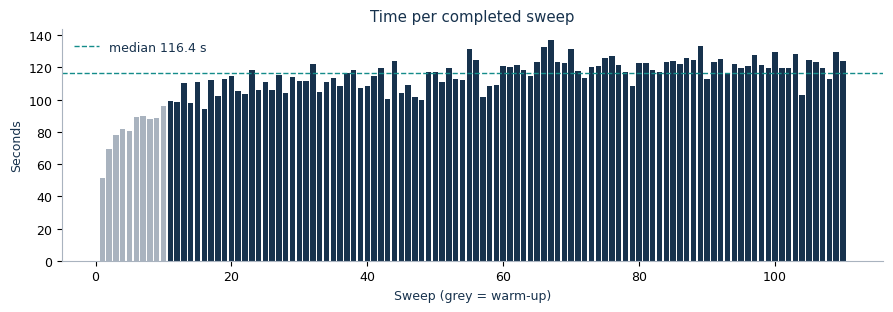

The slow part is the Bayesian correlation step: each iteration turns proposed correlation states into weekly correlation matrices
and evaluates the likelihood of the observed returns. It used **99.7%** of the summed per-chain time
(12,410.7 seconds) and is the main target for speed improvements.

In [26]:
stage = pd.Series(pilot.get("stage_seconds", {}), dtype=float)
chain_stages = stage.drop(labels=[k for k in ("elapsed", "diagnostics") if k in stage.index])
stage_table = pd.DataFrame({"Seconds": chain_stages, "Share": chain_stages / chain_stages.sum()}).sort_values("Seconds", ascending=False)
stage_table = stage_table[stage_table.Seconds > 0]
display(stage_table.style.format({"Seconds": "{:,.2f}", "Share": "{:.1%}"}))

sweeps = np.asarray(pilot.get("sweep_seconds", []), float)
if sweeps.size:
    fig, ax = plt.subplots(figsize=(9, 3.2))
    x = np.arange(1, sweeps.size + 1)
    burnin = int(pilot.get("burnin", 0))
    ax.bar(x, sweeps, color=[GREY if i <= burnin else NAVY for i in x], width=.8)
    ax.axhline(np.median(sweeps), color=TEAL, lw=1, ls="--", label=f"median {np.median(sweeps):.1f} s")
    ax.set(xlabel="Sweep (grey = warm-up)", ylabel="Seconds", title="Time per completed sweep")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "sweep_seconds.png")
    plt.show()
correlation_share = stage.get("correlation", 0) / chain_stages.sum() if chain_stages.sum() else float("nan")
show(f"""The slow part is the Bayesian correlation step: each iteration turns proposed correlation states into weekly correlation matrices
and evaluates the likelihood of the observed returns. It used **{correlation_share:.1%}** of the summed per-chain time
({stage.get('correlation', 0):,.1f} seconds){' and is the main target for speed improvements' if pilot.get('implementation', {}).get('correlation_backend') != 'mex' else ''}.""")

### 8.3 Proposals and storage

In [27]:
proposal_rows = [("Correlation proposals (invalid)", f"{pilot.get('r_proposals', 0):,} ({pilot.get('r_invalid_proposals', 0)})"),
                 ("Volatility proposals (invalid)", f"{pilot.get('h_proposals', 0):,} ({pilot.get('h_invalid_proposals', 0)})")]
for key, label in [("old_dense_brownian_GiB", "Original dense random-walk factors"),
                   ("old_4000_draw_h_r_P_GiB", "Original 4,000-draw h/r/P storage"),
                   ("packed_P_2000_draw_GiB", "Distinct correlations, 2,000 retained draws")]:
    if key in pilot:
        proposal_rows.append((f"{label} (analytical estimate)", f"{pilot[key]:.2f} GiB"))
proposal_rows.append(("Storage policy", pilot.get("storage", "")))
display(pd.DataFrame(proposal_rows, columns=["Quantity", "Value"]).style.hide(axis="index"))

Quantity,Value
Correlation proposals (invalid),"49,781 (0)"
Volatility proposals (invalid),"9,073 (0)"
Original dense random-walk factors (analytical estimate),0.95 GiB
"Original 4,000-draw h/r/P storage (analytical estimate)",9.87 GiB
"Distinct correlations, 2,000 retained draws (analytical estimate)",1.49 GiB
Storage policy,Postburn-in packed P_pairs plus h/B and V/sig2h/sig2r; no r history; one checkpoint; chain identity preserved.


### 8.4 MATLAB test evidence

In [28]:
acceptance = RUN_DIR / "acceptance_tests.json"
test_path = acceptance if acceptance.is_file() else RESULTS_DIR / "matlab_test_results.json"
if test_path.is_file():
    tests = read_json(test_path)
    run_started = datetime.strptime(RUN_DIR.name[:15], "%Y%m%d-%H%M%S")
    tested_at = datetime.fromisoformat(tests["created_at"])
    timing = "before" if tested_at <= run_started else "after"
    show(f"""The saved MATLAB test run (`{test_path.relative_to(RESULTS_DIR).as_posix()}`, MATLAB {tests['matlab_version']}) records
**{tests['passed']} passing**, **{tests['failed']} failing** and {tests['incomplete']} incomplete (filtered) tests in
{tests['duration_seconds']:.0f} seconds. It was written {tests['created_at']}, {timing} this run started. These checks confirm numerical
consistency of the code; they are not convergence evidence.""")
    failures = [t["name"] for t in tests.get("tests", []) if t.get("failed")]
    if failures:
        display(pd.DataFrame({"Failed test": failures}))
else:
    show("No saved MATLAB test results were found.")

The saved MATLAB test run (`matlab_test_results.json`, MATLAB 9.11.0.2358333 (R2021b) Update 7) records
**109 passing**, **0 failing** and 9 incomplete (filtered) tests in
39 seconds. It was written 2026-09-29T18:38:36, before this run started. These checks confirm numerical
consistency of the code; they are not convergence evidence.

## 9. Run diagnostics
The reference values are thresholds for judging whether independently initialized chains agree well enough to trust the posterior summaries: rank-normalized split $\widehat R$ below 1.01, bulk and tail effective sample sizes (ESS) of at least 400, and Monte Carlo standard error below 5% of the posterior SD.

### 9.1 Summary against thresholds

In [29]:
def diagnostic_table(report):
    t = report.get("thresholds", {})
    rhat_t, ess_t, mcse_t = float(t.get("rhat", 1.01)), float(t.get("ess", 400)), float(t.get("mcse_ratio", .05))
    def num(key):
        v = report.get(key)
        return v if isinstance(v, (int, float)) and np.isfinite(v) else None
    rows = [("Maximum rank-normalized split R̂", f"< {rhat_t:.2f}", num("max_rhat"), num("max_rhat") is not None and num("max_rhat") < rhat_t),
            ("Minimum bulk ESS", f"≥ {ess_t:.0f}", num("min_ess_bulk"), num("min_ess_bulk") is not None and num("min_ess_bulk") >= ess_t),
            ("Minimum tail ESS", f"≥ {ess_t:.0f}", num("min_ess_tail"), num("min_ess_tail") is not None and num("min_ess_tail") >= ess_t),
            ("Maximum MCSE / SD", f"≤ {mcse_t:.2f}", num("max_mcse_sd_ratio"), num("max_mcse_sd_ratio") is not None and num("max_mcse_sd_ratio") <= mcse_t),
            ("Retained draws per chain", f"≥ {t.get('min_draws', t.get('min_diagnostic_draws', 100))}", report.get("draws_per_chain"),
             (report.get("draws_per_chain") or 0) >= t.get("min_draws", 100)),
            ("Independent chains", f"≥ {t.get('min_original_chains', 4)}", report.get("chains"), (report.get("chains") or 0) >= t.get("min_original_chains", 4))]
    return pd.DataFrame([{"Diagnostic": d, "Reference": r, "Observed": "Unavailable" if o is None else f"{o:.4g}",
                          "Result": "Pass" if ok else "Fail"} for d, r, o, ok in rows])


reports = {"State smoothing (this run)": convergence}
if inference and "estimation_convergence" in inference:
    reports["Parameter estimation"] = inference["estimation_convergence"]
for name, report in reports.items():
    show(f"**{name}** — status `{report['status']}`; {report.get('quantities_checked', 0):,} quantities checked. "
         f"Scope: {report.get('scope', '')} {report.get('reason', '')}")
    display(diagnostic_table(report).style.hide(axis="index").map(
        lambda v: "color:#B00020" if v == "Fail" else "color:#1B7F3B", subset=["Result"]))
show("**Convergence is not established.**" if not convergence["passed"] else
     "State-chain diagnostics passed; this is not a proof of convergence.")

**State smoothing (this run)** — status `insufficient_chains`; 130,900 quantities checked. Scope: Conditional state smoothing: B/h/P_pairs at every modeled date; fixed parameters excluded. At least four distinct original chains are required; split halves are not original chains.

Diagnostic,Reference,Observed,Result
Maximum rank-normalized split R̂,< 1.01,2.131,Fail
Minimum bulk ESS,≥ 400,1.394,Fail
Minimum tail ESS,≥ 400,12.74,Fail
Maximum MCSE / SD,≤ 0.05,0.9136,Fail
Retained draws per chain,≥ 100,100,Pass
Independent chains,≥ 4,1,Fail


**Parameter estimation** — status `insufficient_chains`; 131,110 quantities checked. Scope: All unique V entries, sig2h, sig2r, and B/h/P_pairs at every modeled date. At least four distinct original chains are required; split halves are not original chains.

Diagnostic,Reference,Observed,Result
Maximum rank-normalized split R̂,< 1.01,2.131,Fail
Minimum bulk ESS,≥ 400,1.391,Fail
Minimum tail ESS,≥ 400,10.52,Fail
Maximum MCSE / SD,≤ 0.05,0.9197,Fail
Retained draws per chain,≥ 100,100,Pass
Independent chains,≥ 4,1,Fail


**Convergence is not established.**

### 9.2 Per-quantity diagnostics
From `convergence_diagnostics.csv`: one row per smoothed quantity (means B, log variances h and correlations P at every modeled week).

,Quantities,MedianRhat,MaxRhat,MedianBulkESS,MedianMCSEratio,Passing
family,,,,,,
B,"15,400",1.009,1.127,90,0.105,0.0%
P_pairs,"100,100",1.136,2.131,8,0.368,0.0%
h,"15,400",1.211,2.131,6,0.448,0.0%


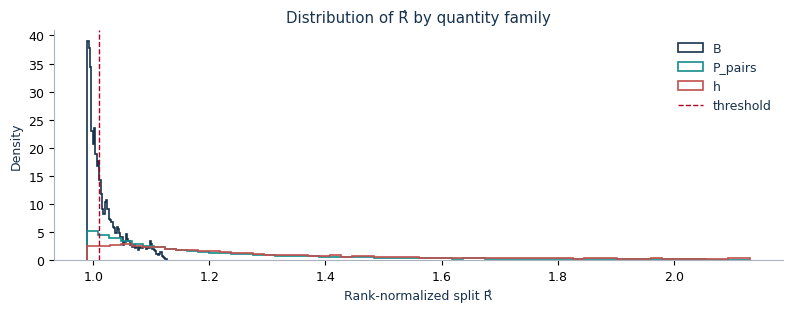

In [30]:
per_quantity = pd.read_csv(RUN_DIR / "convergence_diagnostics.csv")
by_family = per_quantity.groupby("family").agg(
    Quantities=("quantity", "size"), MedianRhat=("rhat", "median"), MaxRhat=("rhat", "max"),
    MedianBulkESS=("ess_bulk", "median"), MedianMCSEratio=("mcse_sd_ratio", "median"), Passing=("passed", "mean"))
display(by_family.style.format({"Quantities": "{:,}", "MedianRhat": "{:.3f}", "MaxRhat": "{:.3f}", "MedianBulkESS": "{:.0f}",
                                "MedianMCSEratio": "{:.3f}", "Passing": "{:.1%}"}))
fig, ax = plt.subplots(figsize=(8, 3.2))
for (family, g), color in zip(per_quantity.groupby("family"), [NAVY, TEAL, "#C0504D", GREY]):
    ax.hist(g.rhat.dropna(), bins=60, histtype="step", lw=1.2, color=color, label=family, density=True)
ax.axvline(float(convergence["thresholds"].get("rhat", 1.01)), color="#B00020", ls="--", lw=1, label="threshold")
ax.set(xlabel="Rank-normalized split R̂", ylabel="Density", title="Distribution of R̂ by quantity family")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "rhat_distribution.png")
plt.show()

## 10. Bayesian correlation paths
### 10.1 Inference scope

In [31]:
band_text = "68% posterior bands from the saved run; they are not simultaneous bands."
scope = ""
if inference:
    scope = (f"Parameters were estimated on {inference['parameter_estimation_start']} to {inference['parameter_estimation_end']}; "
             f"the model was saved at {inference['parameters_estimated_at']} (UTC). State smoothing uses observations through "
             f"{inference['smoothing_end']}. ")
    if inference.get("calibration_weeks", 0):
        scope = (f"The first {inference['calibration_weeks']} weekly returns ({inference['calibration_start']} to "
                 f"{inference['calibration_end']}) are reserved for initial-prior calibration and excluded from the Bayesian likelihood. "
                 "Descriptive tables keep the full sample. " + scope)
    if inference["inference_mode"] == "fixed_parameter_smoothing":
        if inference["parameter_smoothing"] == "draws":
            scope += ("The saved parameter draws are reused while the mean, volatility and correlation states are jointly smoothed; "
                      "the bands include variation across those draws. ")
            band_text = "68% conditional posterior bands using saved parameter draws; they are not simultaneous bands."
        else:
            scope += ("The posterior-mean parameter estimates stay fixed while the mean, volatility and correlation states are jointly "
                      "smoothed. The bands show state uncertainty conditional on those parameters; they exclude parameter uncertainty. ")
            band_text = "68% conditional posterior bands with posterior-mean parameters fixed; they exclude parameter uncertainty and are not simultaneous bands."
    else:
        scope += "These bands use joint parameter and state draws and include parameter uncertainty. "
    scope += "Historical state estimates can change when later observations are included."
status_text = ("State-chain diagnostics passed; this is not a proof of convergence." if convergence["passed"] else
               "State-chain convergence has not been established, so the bands are preliminary.")
show(f"""{scope}

The run retained **{draws:,} draws** pooled across {chains} chain(s), after discarding {warmup:,} warm-up iterations per chain.
The dark line is the posterior median of the correlation $P_{{ij,t}}$; the grey envelope spans the pointwise 16th and 84th percentiles.
Background colors use the same continuous scale as the full-sample heatmap (blue negative, white near zero, red positive), with intensity set
by the posterior median. **{status_text}** Bands: {band_text}""")
if inference:
    show(f"Saved parameter file: `{inference['parameter_file']}`")

The first 104 weekly returns (2003-08-15 to 2005-08-05) are reserved for initial-prior calibration and excluded from the Bayesian likelihood. Descriptive tables keep the full sample. Parameters were estimated on 2005-08-12 to 2026-09-04; the model was saved at 2026-09-29T21:02:41.038Z (UTC). State smoothing uses observations through 2026-09-04. The posterior-mean parameter estimates stay fixed while the mean, volatility and correlation states are jointly smoothed. The bands show state uncertainty conditional on those parameters; they exclude parameter uncertainty. Historical state estimates can change when later observations are included.

The run retained **100 draws** pooled across 1 chain(s), after discarding 10 warm-up iterations per chain.
The dark line is the posterior median of the correlation $P_{ij,t}$; the grey envelope spans the pointwise 16th and 84th percentiles.
Background colors use the same continuous scale as the full-sample heatmap (blue negative, white near zero, red positive), with intensity set
by the posterior median. **State-chain convergence has not been established, so the bands are preliminary.** Bands: 68% conditional posterior bands with posterior-mean parameters fixed; they exclude parameter uncertainty and are not simultaneous bands.

Saved parameter file: `C:\Users\Jules.Viard\Documents\GitHub\DSC-AC-model\outputs\weekly_research\parameters\dsc_parameters_20260929T210241038Z_312a5ba6-0717-49cc-b098-c4b989f34232.mat`

### 10.2 Posterior bands and cross-check against the draws
The bands are read from `posterior_correlation_bands.mat`. They are then recomputed from the saved posterior draws with MATLAB's `prctile` convention (Hazen plotting positions).

In [32]:
S = "Bands"
with h5py.File(RUN_DIR / "posterior_correlation_bands.mat", "r") as f:   # MATLAB v7.3 = HDF5, stored transposed
    lower, median_path, upper = (f[k][()].T for k in ("lower", "median_path", "upper"))
    band_i, band_j = (f[k][()].ravel().astype(int) for k in ("pair_i", "pair_j"))
T_model = int(pilot["T"])
model_dates = dates[excluded:excluded + T_model]
pair_names = [f"{short(tickers[i - 1])} / {short(tickers[j - 1])}" for i, j in zip(band_i, band_j)]
check(S, "Band arrays are modeled weeks × pairs", median_path.shape == lower.shape == upper.shape == (T_model, q), f"{median_path.shape}")
check(S, "Band pair order matches the correlation tables",
      [(tickers[i - 1], tickers[j - 1]) for i, j in zip(band_i, band_j)] == expected_pairs)
check(S, "Model dates end on the last return", ymd(model_dates[-1]) == pilot["last_date"] and ymd(model_dates[0]) == pilot["first_date"])
check(S, "16th ≤ median ≤ 84th percentile, all within [−1, 1]",
      bool((lower <= median_path + 1e-12).all() and (median_path <= upper + 1e-12).all() and (np.abs([lower, upper]) <= 1).all()))

MAX_DRAWS_TO_RELOAD = 500   # 2,000 draws would need about 1.6 GB of memory
if draws <= MAX_DRAWS_TO_RELOAD:
    chain_dirs = [Path(d) for d in as_list(pilot.get("chain_dirs", [str(RUN_DIR)]))]
    chain_dirs = [d if d.is_dir() else RUN_DIR for d in chain_dirs]
    blocks = []
    for d in chain_dirs:
        for chunk in sorted(d.glob("posterior_chunk_*.mat")):
            with h5py.File(chunk, "r") as f:
                blocks.append(np.transpose(f["chunk/P_pairs"][()], (2, 1, 0)))   # -> weeks × pairs × draws
    P_draws = np.concatenate(blocks, axis=2)
    recomputed = np.percentile(P_draws, [16, 50, 84], axis=2, method="hazen")
    err = max(np.abs(recomputed[0] - lower).max(), np.abs(recomputed[1] - median_path).max(), np.abs(recomputed[2] - upper).max())
    check(S, "Posterior draw count matches the run", P_draws.shape[2] == draws, f"{P_draws.shape[2]} draws")
    check(S, "Saved bands reproduce from the posterior draws", err < 1e-10, f"max abs. difference {err:.1e}")
else:
    check(S, "Saved bands reproduce from the posterior draws", None, f"{draws} draws; reload skipped to save memory")
check_report(S)

Check,Result,Detail
Band arrays are modeled weeks × pairs,pass,"(1100, 91)"
Band pair order matches the correlation tables,pass,
Model dates end on the last return,pass,
"16th ≤ median ≤ 84th percentile, all within [−1, 1]",pass,
Posterior draw count matches the run,pass,100 draws
Saved bands reproduce from the posterior draws,pass,max abs. difference 6.9e-18


### 10.3 Selected paths
Same selection rule as the MATLAB figure: TUKXG / SX5T and SX5T / BCOMCOT, then the pairs with the largest peak absolute median plus range, six in total.

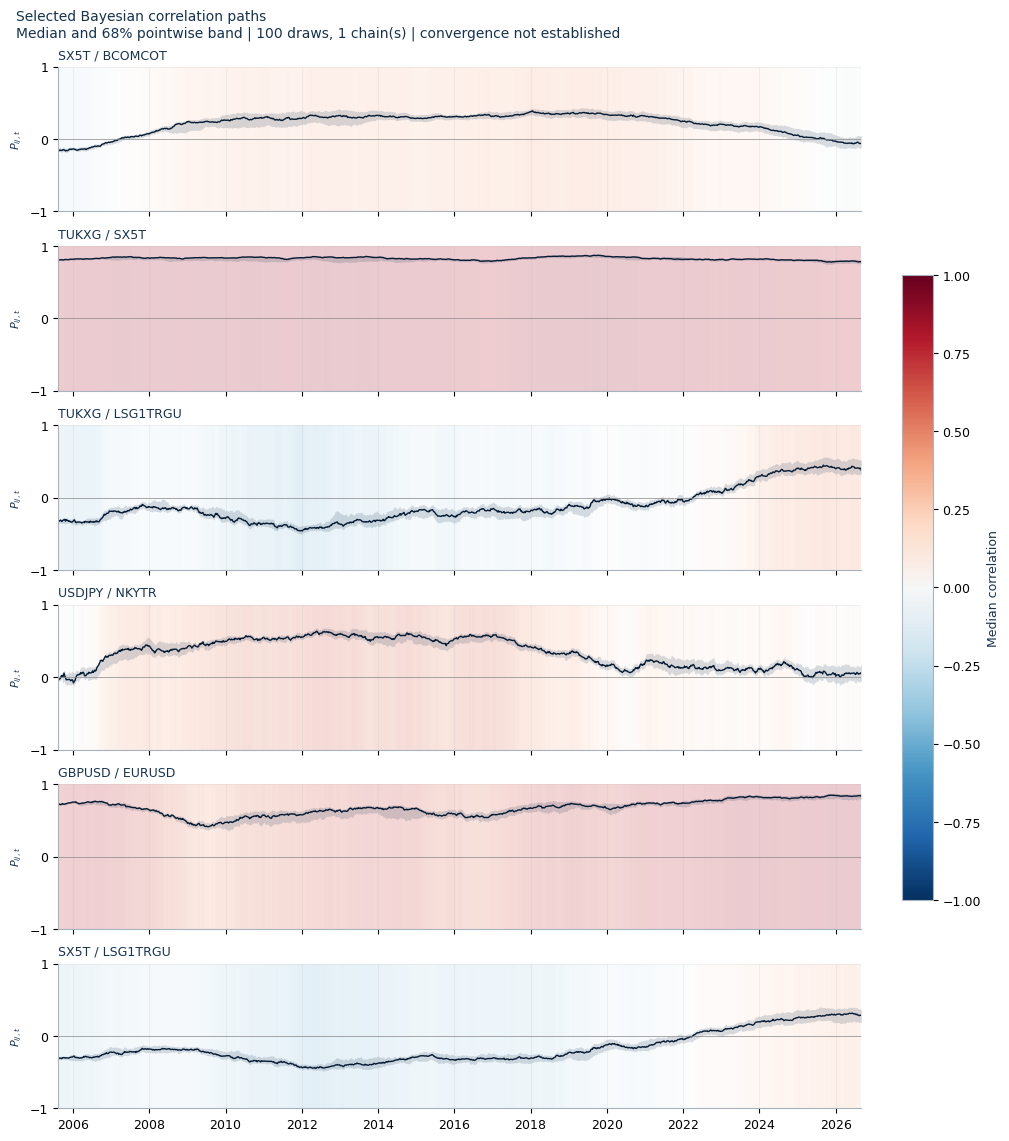

In [33]:
cutoff = pd.Timestamp(inference["parameter_estimation_end"]) if inference else None


def bayes_plot(indices, title, filename=None):
    x = mdates.date2num(model_dates.to_pydatetime())
    edges = np.r_[x[0], (x[:-1] + x[1:]) / 2, x[-1]]
    fig, axes = plt.subplots(len(indices), 1, figsize=(10, 1.75 * len(indices) + .8), squeeze=False, sharex=True,
                             layout="constrained")
    for ax, k in zip(axes[:, 0], indices):
        mesh = ax.pcolormesh(edges, [-1, 1], median_path[:, k][None, :], cmap="RdBu_r", vmin=-1, vmax=1,
                             alpha=.22, shading="flat", rasterized=True)
        ax.fill_between(x, lower[:, k], upper[:, k], color=(0.08, 0.19, 0.31), alpha=.16, lw=0)
        ax.plot(x, median_path[:, k], color=(0.02, 0.10, 0.20), lw=1.0)
        ax.axhline(0, color="#8C8C8C", lw=.5)
        if cutoff is not None and model_dates[0] < cutoff < model_dates[-1]:
            ax.axvline(mdates.date2num(cutoff), color="#404040", ls="--", lw=.9)
        ax.set(ylim=(-1, 1), xlim=(x[0], x[-1]), yticks=[-1, 0, 1])
        ax.set_ylabel("$P_{ij,t}$", fontsize=8)
        ax.set_title(pair_names[k], loc="left", fontsize=9)
        ax.grid(alpha=.15)
    axes[-1, 0].xaxis_date()
    axes[-1, 0].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"), ax=axes[:, 0].tolist(),
                 shrink=.6, label="Median correlation", ticks=np.linspace(-1, 1, 9))
    fig.suptitle(f"{title}\nMedian and 68% pointwise band | {draws} draws, {chains} chain(s) | "
                 f"{'convergence diagnostics passed' if convergence['passed'] else 'convergence not established'}",
                 fontsize=10, x=.01, ha="left")
    if filename:
        save_figure(fig, filename)
    plt.show()


score = np.abs(median_path).max(0) + (median_path.max(0) - median_path.min(0))
order = np.argsort(-score, kind="stable")
must = [k for k, name in enumerate(pair_names) if name in ("TUKXG / SX5T", "SX5T / BCOMCOT")]
selected = list(dict.fromkeys(must + order[:6].tolist()))[:6]
bayes_plot(selected, "Selected Bayesian correlation paths", "bayes_paths_selected.png")

### 10.4 Bayesian and rolling estimates compared
Latest posterior median (with 68% band) against the latest rolling and full-sample correlations, for the reference pairs of Section 5.

In [34]:
compare = pd.DataFrame([{
    "Pair": pair_label(r.TickerI, r.TickerJ),
    "Posterior median": median_path[-1, int(r.PairIndex) - 1],
    "16th pct.": lower[-1, int(r.PairIndex) - 1], "84th pct.": upper[-1, int(r.PairIndex) - 1],
    "Latest 52-week": latest52.loc[r.PairIndex, "Correlation"], "Latest 104-week": latest(104, r.PairIndex),
    "Full sample": r.Correlation,
    "Posterior median, model-period average": median_path[:, int(r.PairIndex) - 1].mean()} for r in reference_pairs])
display(compare.style.hide(axis="index").format(precision=2))
save_table(compare, "bayes_vs_rolling.csv")
show(f"Values at {ymd(model_dates[-1])}. The posterior bands are conditional and pointwise; see Section 10.1 for their scope.")

Pair,Posterior median,16th pct.,84th pct.,Latest 52-week,Latest 104-week,Full sample,"Posterior median, model-period average"
SX5T / SPXT,0.74,0.68,0.78,0.66,0.62,0.78,0.74
SPXT / NKYTR,0.60,0.52,0.65,0.47,0.51,0.63,0.58
SPXT / LUATTRUU,0.10,-0.00,0.19,0.26,-0.04,-0.23,-0.23
SX5T / LEATTREU,0.21,0.16,0.30,0.54,0.20,0.01,-0.01
GBPUSD / EURUSD,0.84,0.79,0.87,0.86,0.84,0.64,0.67
USDJPY / AUDUSD,-0.38,-0.46,-0.28,-0.51,-0.41,-0.10,-0.23


Values at 2026-09-04. The posterior bands are conditional and pointwise; see Section 10.1 for their scope.

## 11. Independent verification of the MATLAB exports
This section replaces `tests/verify_exports.py`. It rebuilds the weekly panel from the immutable source CSV using pandas only, then recomputes every exported correlation. It shares no code with the MATLAB preparation.

### 11.1 Weekly panel from the raw source

In [35]:
S = "Verification"
if not source_file.is_file():
    check(S, "Source CSV available", None, f"not found: {source_file}")
else:
    source_tickers = source_file.read_text().splitlines()[1].split(",")[1:]
    raw = pd.read_csv(source_file, skiprows=3, header=None, names=["Date"] + source_tickers)
    raw.index = pd.to_datetime(raw.pop("Date"), format="%d/%m/%Y")
    raw = raw[tickers]
    check(S, "Raw dates are unique and increasing", raw.index.is_unique and raw.index.is_monotonic_increasing,
          f"{len(raw):,} rows, {ymd(raw.index[0])} to {ymd(raw.index[-1])}")
    check(S, "Raw row and missing-cell counts match data_summary.json",
          len(raw) == summary["raw_rows"] and int(raw.isna().sum().sum()) == summary["raw_missing_cells"],
          f"{len(raw):,} rows, {int(raw.isna().sum().sum()):,} missing cells")
    # Partial first and last calendar weeks are dropped, as in prepare_weekly_panel.m.
    first_friday = raw.index[0] + pd.Timedelta(days=(-raw.index[0].weekday()) % 7 + 4)
    last_friday = raw.index[-1] - pd.Timedelta(days=(raw.index[-1].weekday() - 4) % 7)
    fridays = pd.date_range(first_friday, last_friday, freq="7D")
    check(S, "Rows after the last complete week match data_summary.json",
          int((raw.index > last_friday).sum()) == summary["excluded_final_raw_rows"], f"{int((raw.index > last_friday).sum())} rows")
    expected_levels = raw.reindex(raw.index.union(fridays)).ffill().loc[fridays]
    expected_returns = 100 * np.diff(np.log(expected_levels.to_numpy(float)), axis=0)
    check(S, "Friday calendar matches the exported level dates", levels.index.equals(fridays), f"{len(fridays):,} Fridays")
    check(S, "Levels match the as-of rule", np.allclose(levels.to_numpy(float), expected_levels.to_numpy(float), rtol=1e-12, atol=1e-12))
    check(S, "Returns match 100 × Δ log of the as-of levels",
          np.allclose(returns.to_numpy(float), expected_returns, rtol=1e-9, atol=1e-10))
    observed = pd.DataFrame({t: pd.Series(raw.index, index=raw.index).where(raw[t].notna()) for t in tickers})
    observed = observed.reindex(observed.index.union(fridays)).ffill().loc[fridays]
    expected_age = (fridays.values[:, None] - observed.to_numpy("datetime64[ns]")).astype("timedelta64[D]").astype(int)
    saved_age = quality.pivot(index="LevelDate", columns="Ticker", values="AgeDays").loc[fridays, tickers].to_numpy()
    check(S, "Endpoint ages match the source dates", np.array_equal(saved_age, expected_age))
    check(S, "Carried endpoint count matches data_summary.json", int((expected_age > 0).sum()) == summary["carried_endpoint_cells"],
          f"{int((expected_age > 0).sum())} carried cells")

### 11.2 Full-sample and rolling correlations

In [36]:
masked = returns.copy()
for r in return_quality[return_quality.ObservedForModel.eq(0)].itertuples():
    masked.loc[r.Date, r.Ticker] = np.nan
pi = np.array([index_of[t] for t in full.TickerI])
pj = np.array([index_of[t] for t in full.TickerJ])
full_err, n_ok = 0.0, True
for row, i, j in zip(full.itertuples(), pi, pj):
    pair = masked.iloc[:, [i, j]].dropna()
    full_err = max(full_err, abs(pair.corr().iloc[0, 1] - row.Correlation))
    n_ok &= row.N == len(pair)
check(S, "Full-sample correlations and counts", full_err < 1e-12 and n_ok, f"max abs. error {full_err:.1e}")

X = masked.to_numpy(float)
for w in (52, 104):
    sample = rolling[rolling.Window.eq(w)].sort_values(["Date", "PairIndex"])
    saved_corr = sample.Correlation.to_numpy().reshape(-1, q)
    saved_n = sample.N.to_numpy().reshape(-1, q)
    max_err, counts_ok, empty_ok = 0.0, True, True
    for k, end in enumerate(range(w, len(X) + 1)):
        block = X[end - w:end]
        complete = np.isfinite(block).all(0)
        C = np.full((m, m), np.nan)
        if complete.sum() >= 2:
            C[np.ix_(complete, complete)] = np.corrcoef(block[:, complete], rowvar=False)
        n = (np.isfinite(block[:, pi]) & np.isfinite(block[:, pj])).sum(0)
        counts_ok &= np.array_equal(n, saved_n[k])
        full_window = n == w
        empty_ok &= bool(np.isnan(saved_corr[k, ~full_window]).all())
        if full_window.any():
            max_err = max(max_err, np.abs(C[pi, pj][full_window] - saved_corr[k, full_window]).max())
    check(S, f"{w}-week rolling correlations ({saved_corr.size:,} values)", max_err < 1e-12 and counts_ok and empty_ok,
          f"max abs. error {max_err:.1e}; incomplete windows left empty: {empty_ok}")
check_report(S)

Check,Result,Detail
Raw dates are unique and increasing,pass,"6,029 rows, 2003-08-04 to 2026-09-10"
Raw row and missing-cell counts match data_summary.json,pass,"6,029 rows, 1,883 missing cells"
Rows after the last complete week match data_summary.json,pass,4 rows
Friday calendar matches the exported level dates,pass,"1,205 Fridays"
Levels match the as-of rule,pass,
Returns match 100 × Δ log of the as-of levels,pass,
Endpoint ages match the source dates,pass,
Carried endpoint count matches data_summary.json,pass,343 carried cells
Full-sample correlations and counts,pass,max abs. error 2.6e-15
"52-week rolling correlations (104,923 values)",pass,max abs. error 1.9e-15; incomplete windows left empty: True


## 12. Summary of findings

In [37]:
check_totals = pd.DataFrame(CHECKS).Result.value_counts()
show(f"""
**Panel.** {len(returns):,} Friday-to-Friday weekly returns ({first} to {last}) for {m} market variables and {q} distinct pairs. Each Friday
row uses every series' last published level on or before that Friday, so a local holiday does not remove the week for every market.
{summary['carried_endpoint_cells']:,} of {summary['n_levels'] * m:,} weekly level cells ({100 * summary['carried_endpoint_fraction']:.1f}%)
come from an earlier day; the oldest is {summary['max_age_days']} days, at the flagged 2019 NKYTR closure.

**Correlations.** The strongest full-sample correlation is {pair_label(strong.TickerI, strong.TickerJ)} ({strong.Correlation:.2f}).
The widest 52-week path is {pair_label(widest.TickerI, widest.TickerJ)}, ranging from {ranges.loc[widest.PairIndex, 'min']:.2f}
to {ranges.loc[widest.PairIndex, 'max']:.2f}. {int(changes[changes.Window.eq(52)].CrossesZero.sum())} of {q} pairs change sign over their 52-week path.

**Stationarity.** ADF rejects a unit root for {adf_rejections} of {len(adf)} return series; KPSS at 13 weeks flags
{', '.join(kpss13_flags) or 'none'}. Log levels are broadly non-stationary. Returns show volatility clustering (ARCH effects in
{int(arch['sum'])} of {int(arch['count'])} series), which supports time-varying volatility in the model.

**Bayesian run.** {completed} iterations ({pilot.get('burnin')} warm-up) in {float(elapsed) / 60:.1f} minutes, about
{float(per_iteration):.0f} seconds per iteration, retaining {draws} draws from {chains} chain(s). Diagnostic status:
`{convergence['status']}` (max R̂ {convergence['max_rhat']:.3g}, min bulk ESS {convergence['min_ess_bulk']:.1f}).
{status_text} The thresholds need at least {convergence['thresholds'].get('min_original_chains', 4)} chains and
{convergence['thresholds'].get('min_draws', 100)} draws per chain.

**Checks.** {check_totals.get('pass', 0)} consistency checks passed, {check_totals.get('FAIL', 0)} failed, {check_totals.get('skipped', 0)} skipped.
""")


**Panel.** 1,204 Friday-to-Friday weekly returns (2003-08-15 to 2026-09-04) for 14 market variables and 91 distinct pairs. Each Friday
row uses every series' last published level on or before that Friday, so a local holiday does not remove the week for every market.
343 of 16,870 weekly level cells (2.0%)
come from an earlier day; the oldest is 7 days, at the flagged 2019 NKYTR closure.

**Correlations.** The strongest full-sample correlation is TUKXG / SX5T (0.87).
The widest 52-week path is SX5T / BCOMCOT, ranging from -0.55
to 0.83. 76 of 91 pairs change sign over their 52-week path.

**Stationarity.** ADF rejects a unit root for 14 of 14 return series; KPSS at 13 weeks flags
I02981JP, LEATTREU, LSG1TRGU. Log levels are broadly non-stationary. Returns show volatility clustering (ARCH effects in
14 of 14 series), which supports time-varying volatility in the model.

**Bayesian run.** 110 iterations (10 warm-up) in 208.3 minutes, about
113 seconds per iteration, retaining 100 draws from 1 chain(s). Diagnostic status:
`insufficient_chains` (max R̂ 2.13, min bulk ESS 1.4).
State-chain convergence has not been established, so the bands are preliminary. The thresholds need at least 4 chains and
100 draws per chain.

**Checks.** 50 consistency checks passed, 0 failed, 0 skipped.


## Appendix A — All rolling-correlation paths
Pairs are numbered in the export's column-major lower-triangle order.

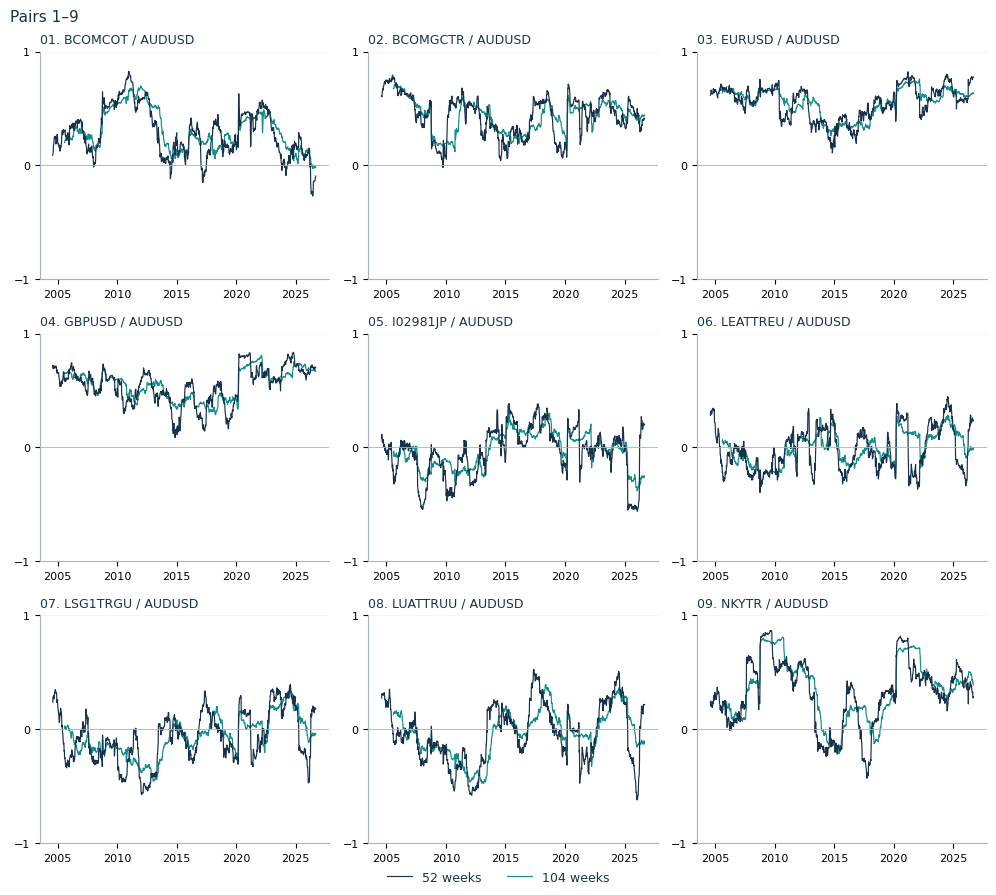

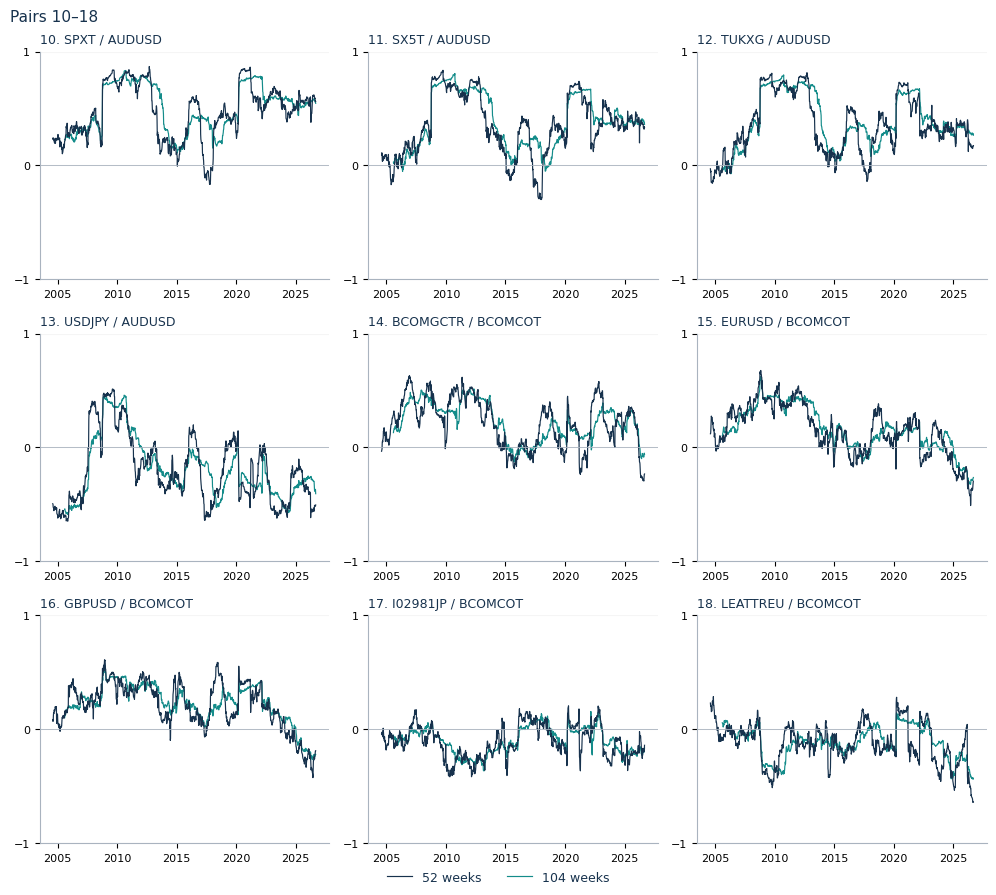

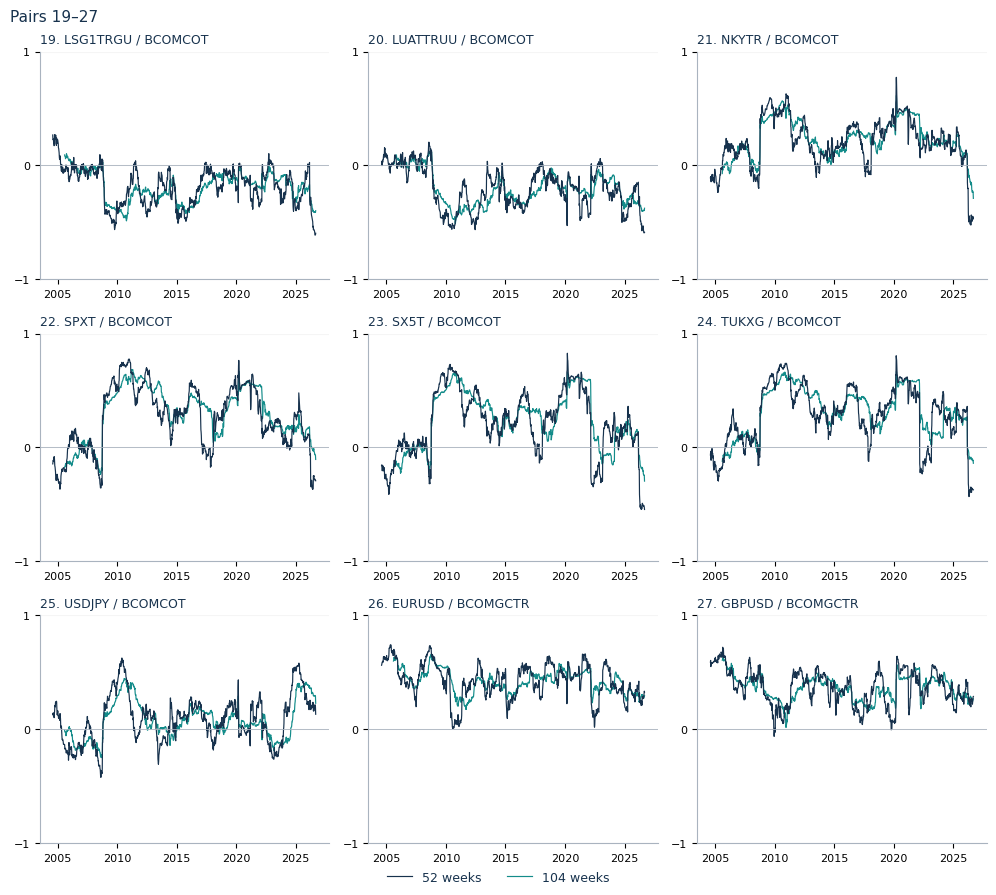

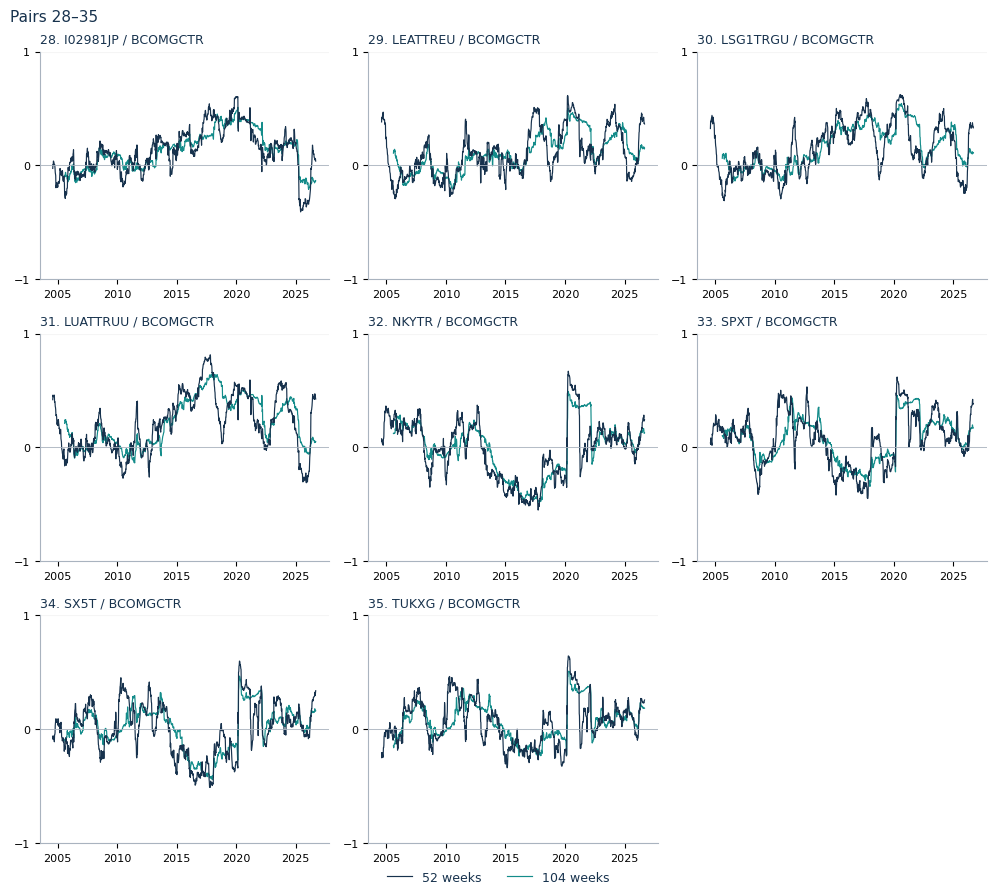

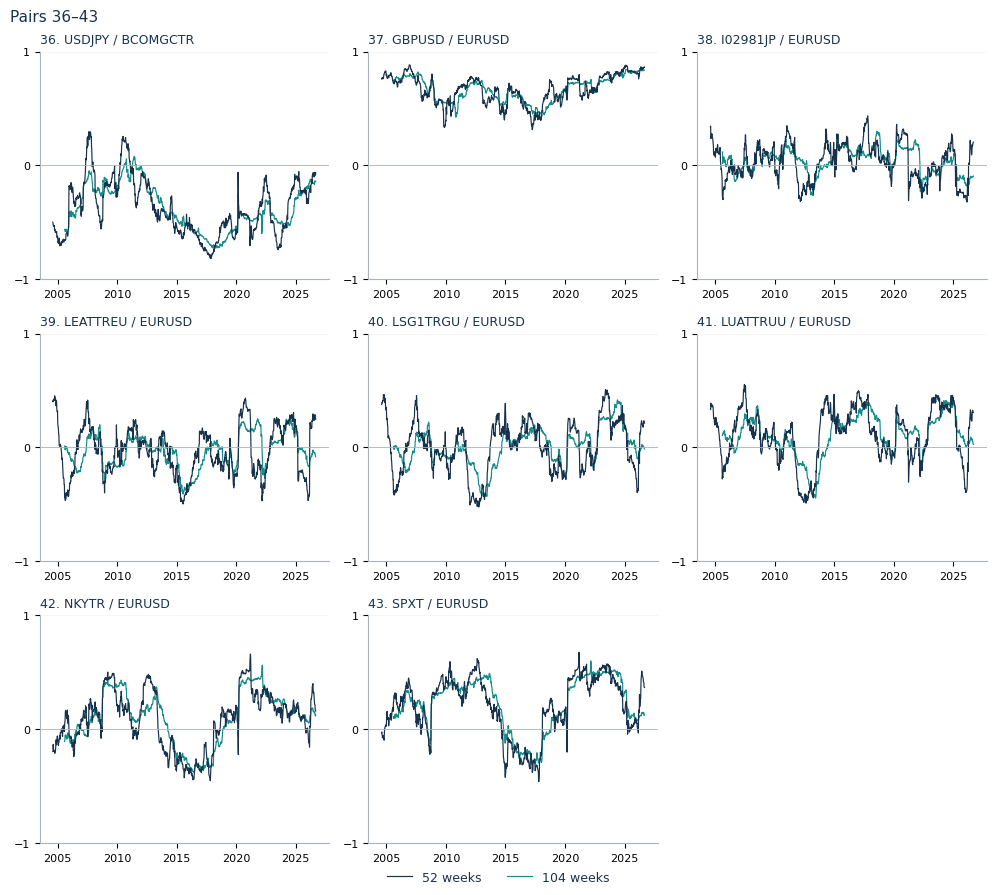

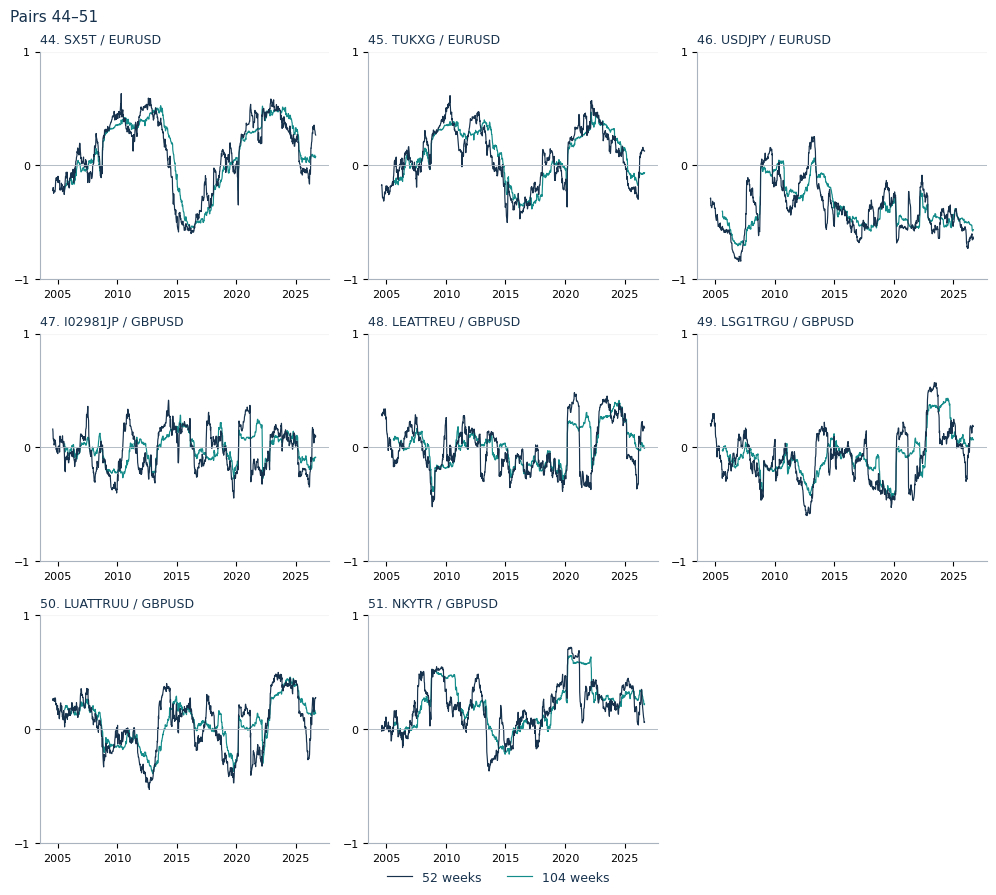

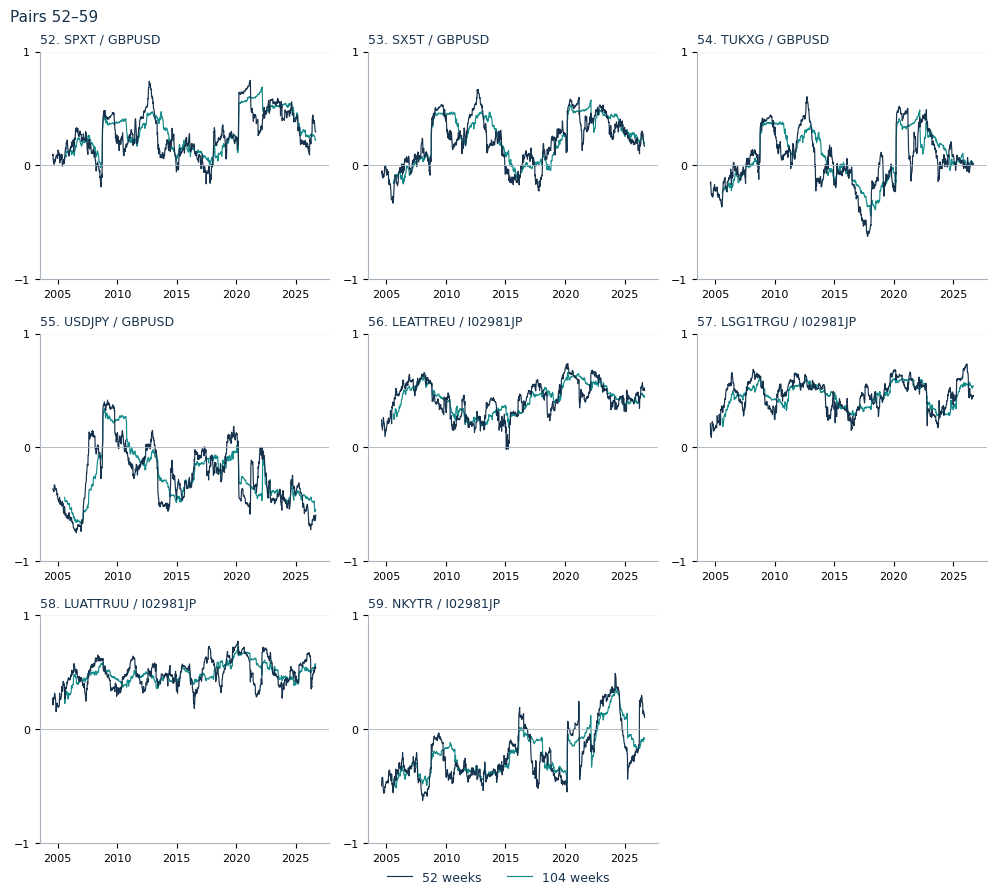

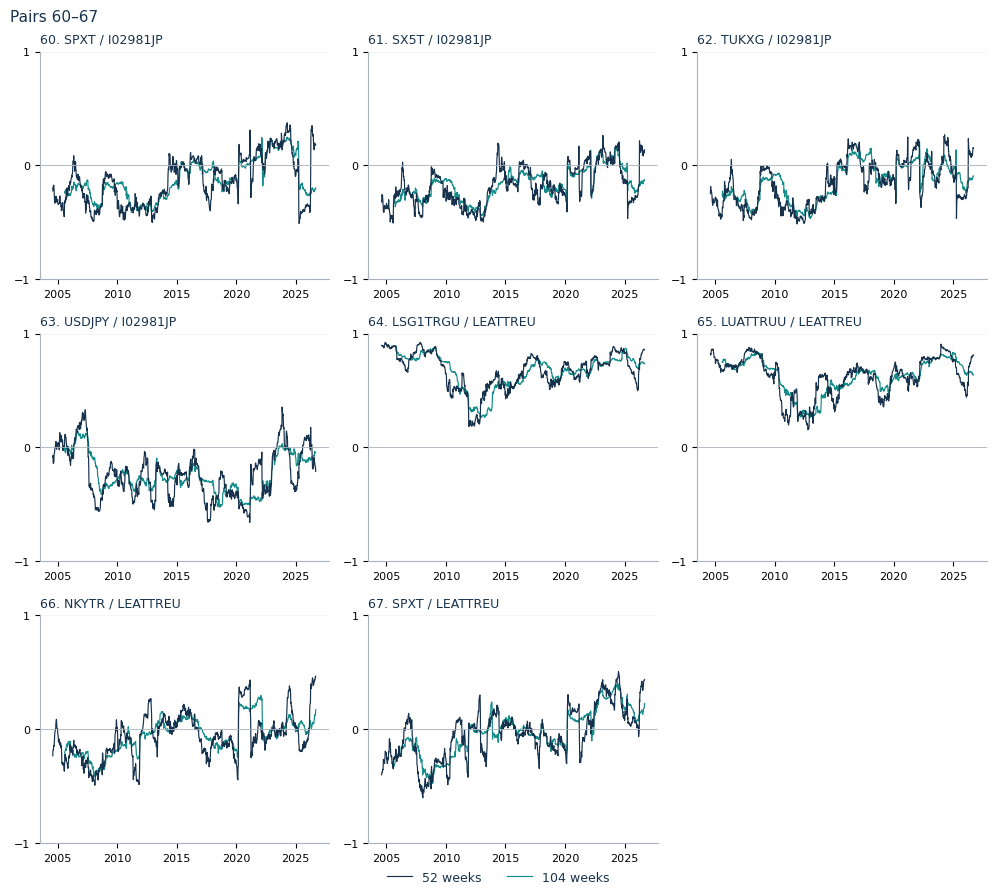

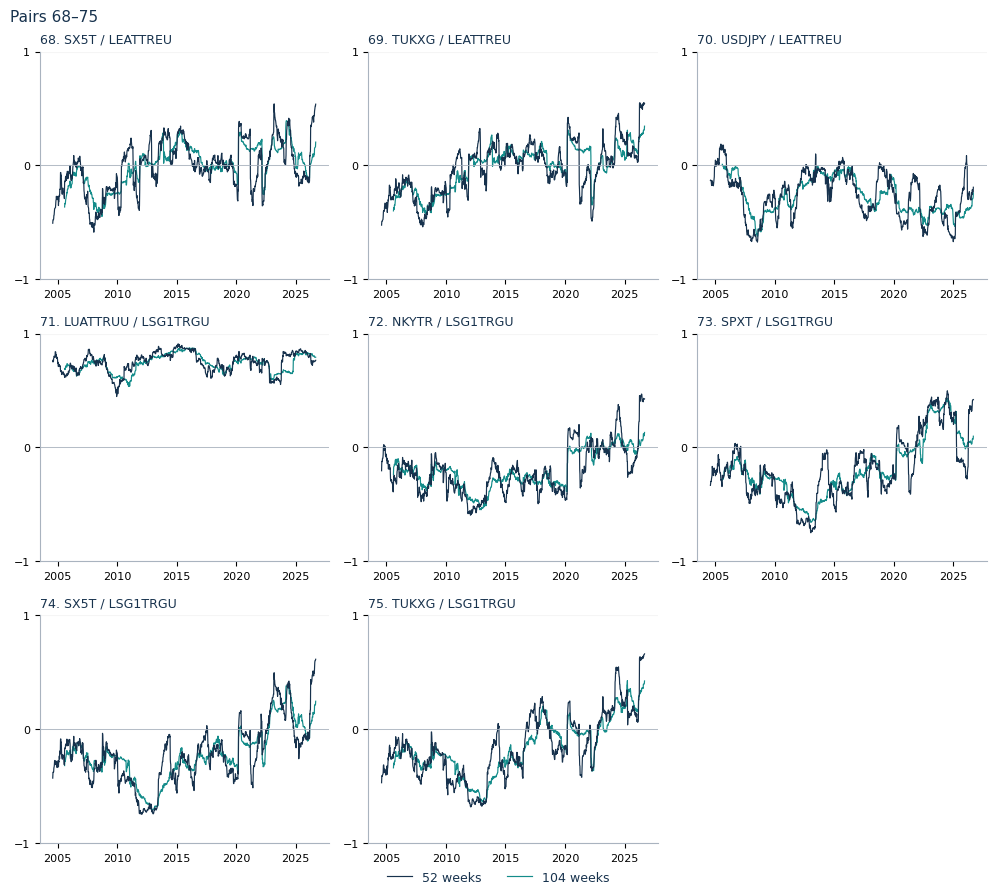

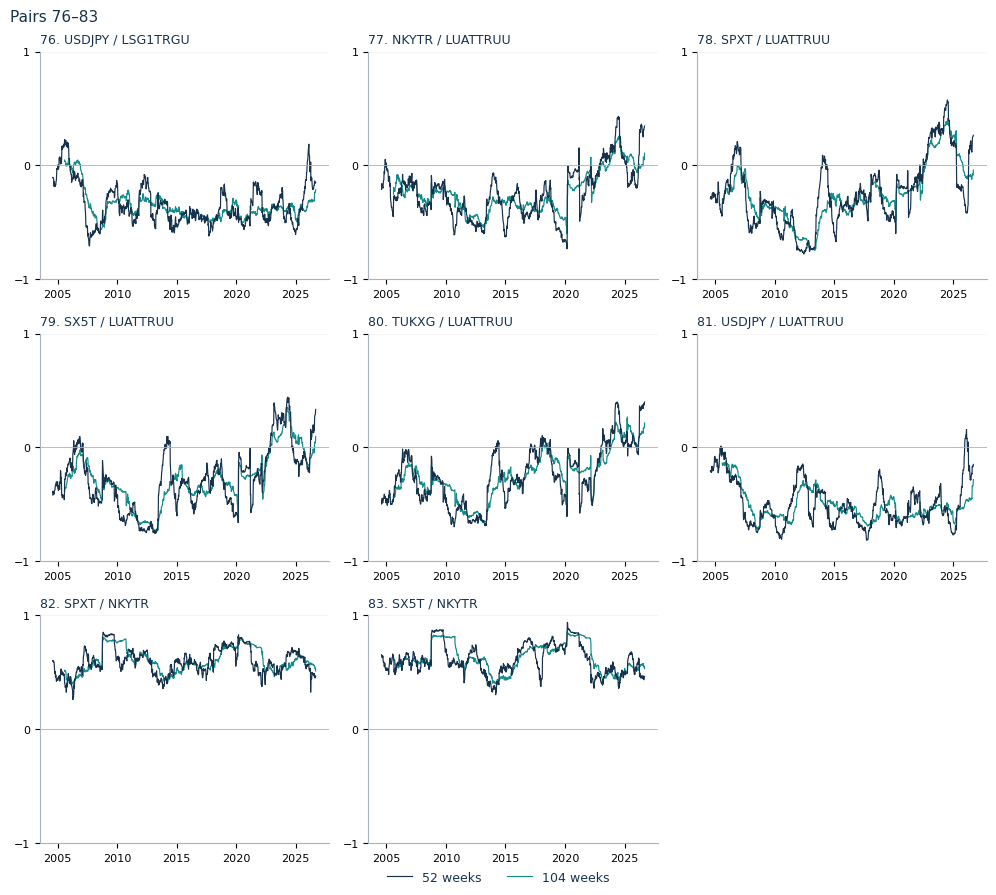

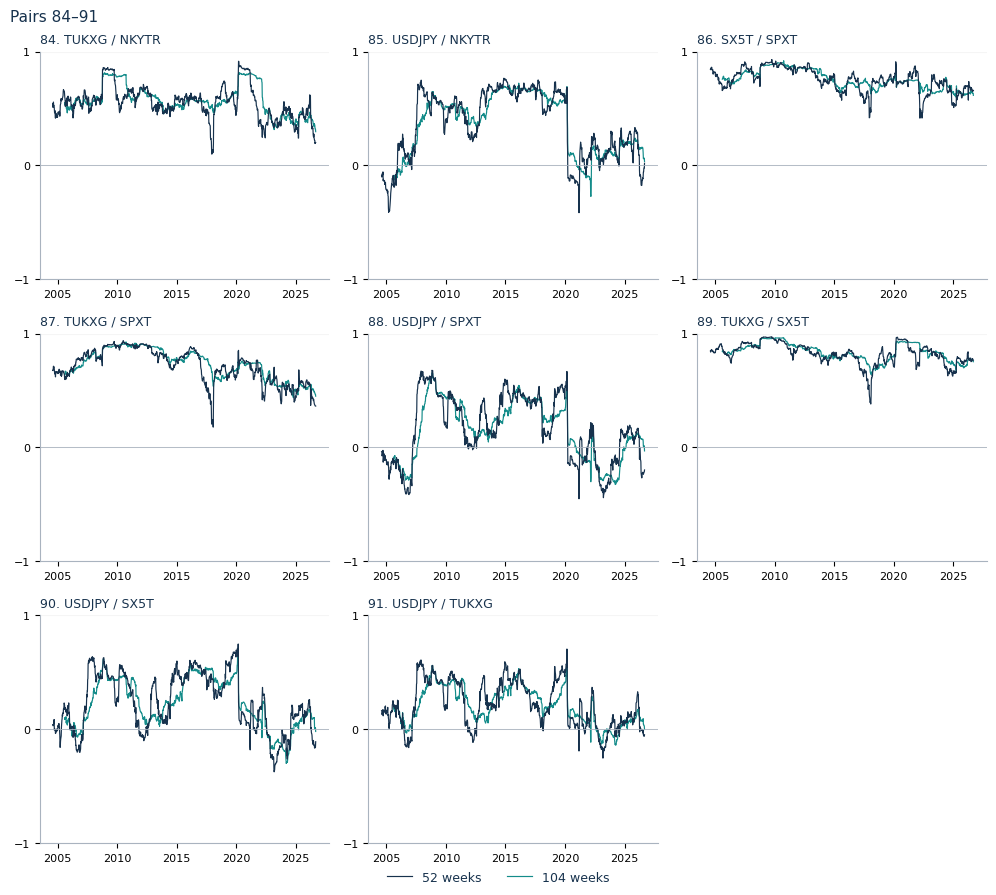

In [38]:
all_rows = list(full.itertuples())
page_sizes = [9, 9, 9] + [8] * 8 if q == 91 else [9] * -(-q // 9)
start = 0
for page, size in enumerate(page_sizes, 1):
    rows = all_rows[start:start + size]
    rolling_plot(rows, f"all_pairs_{page:02d}.png", ncols=3, height=3.0, numbered=True, width=10,
                 title=f"Pairs {start + 1}–{start + len(rows)}")
    start += size

## Appendix B — All Bayesian correlation paths
Every page uses the same vertical scale, color scale and posterior summaries.

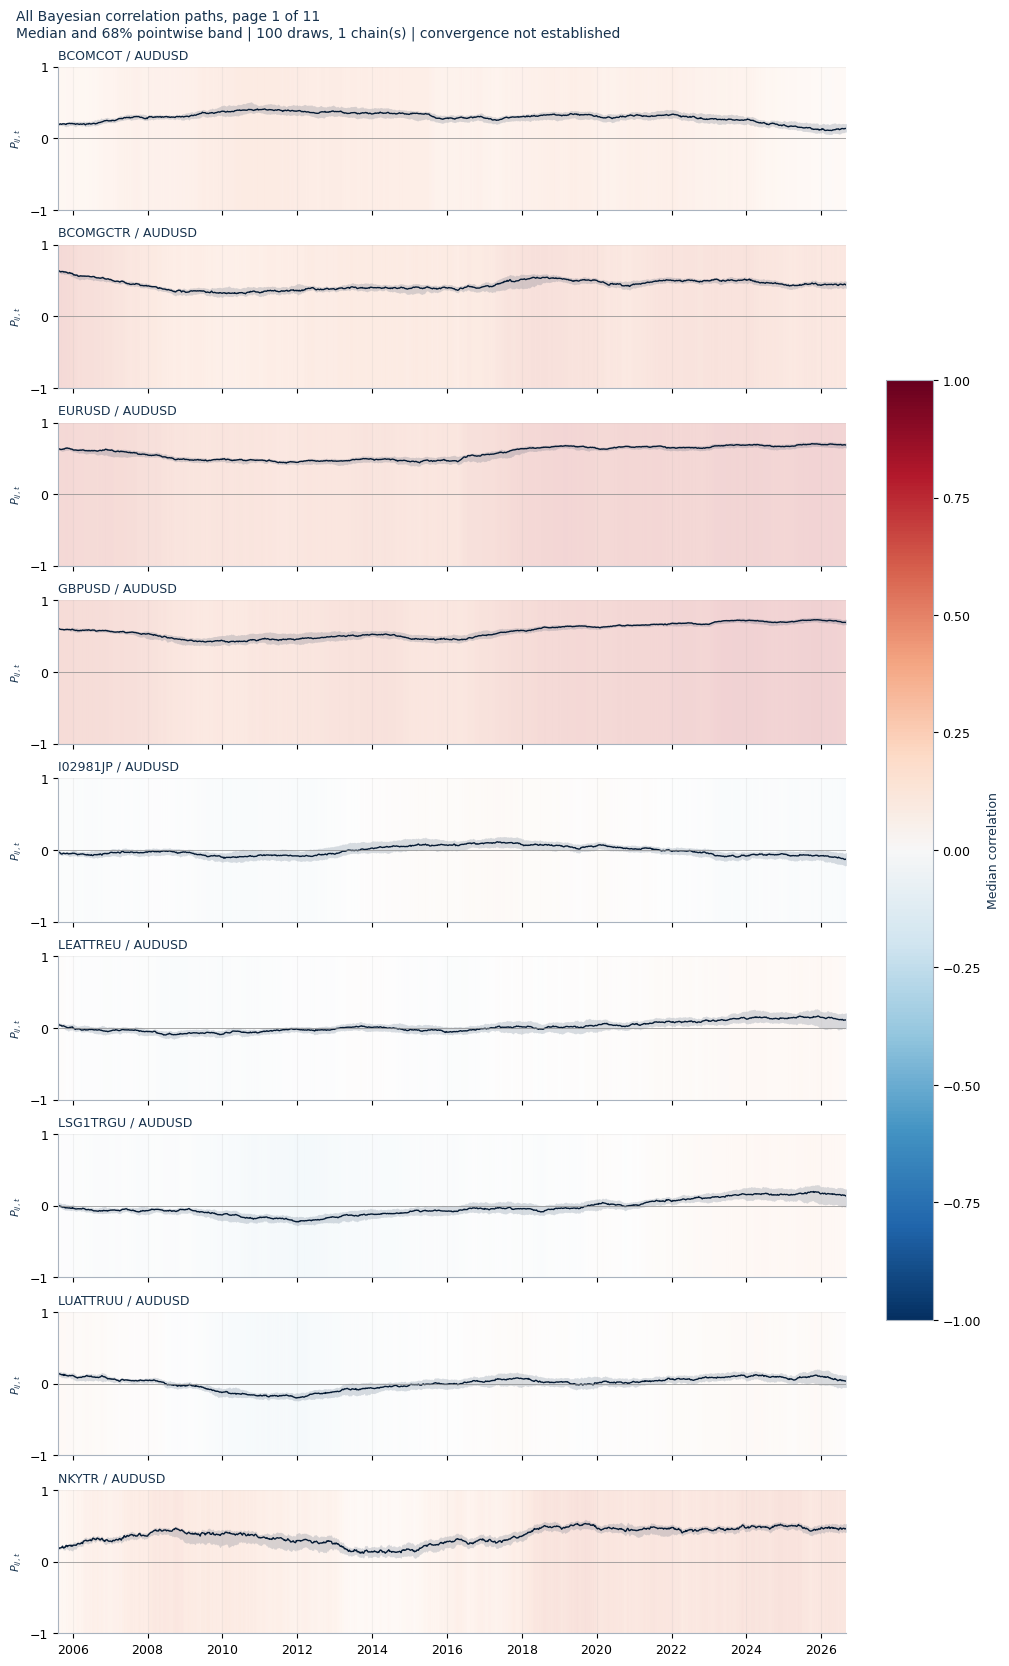

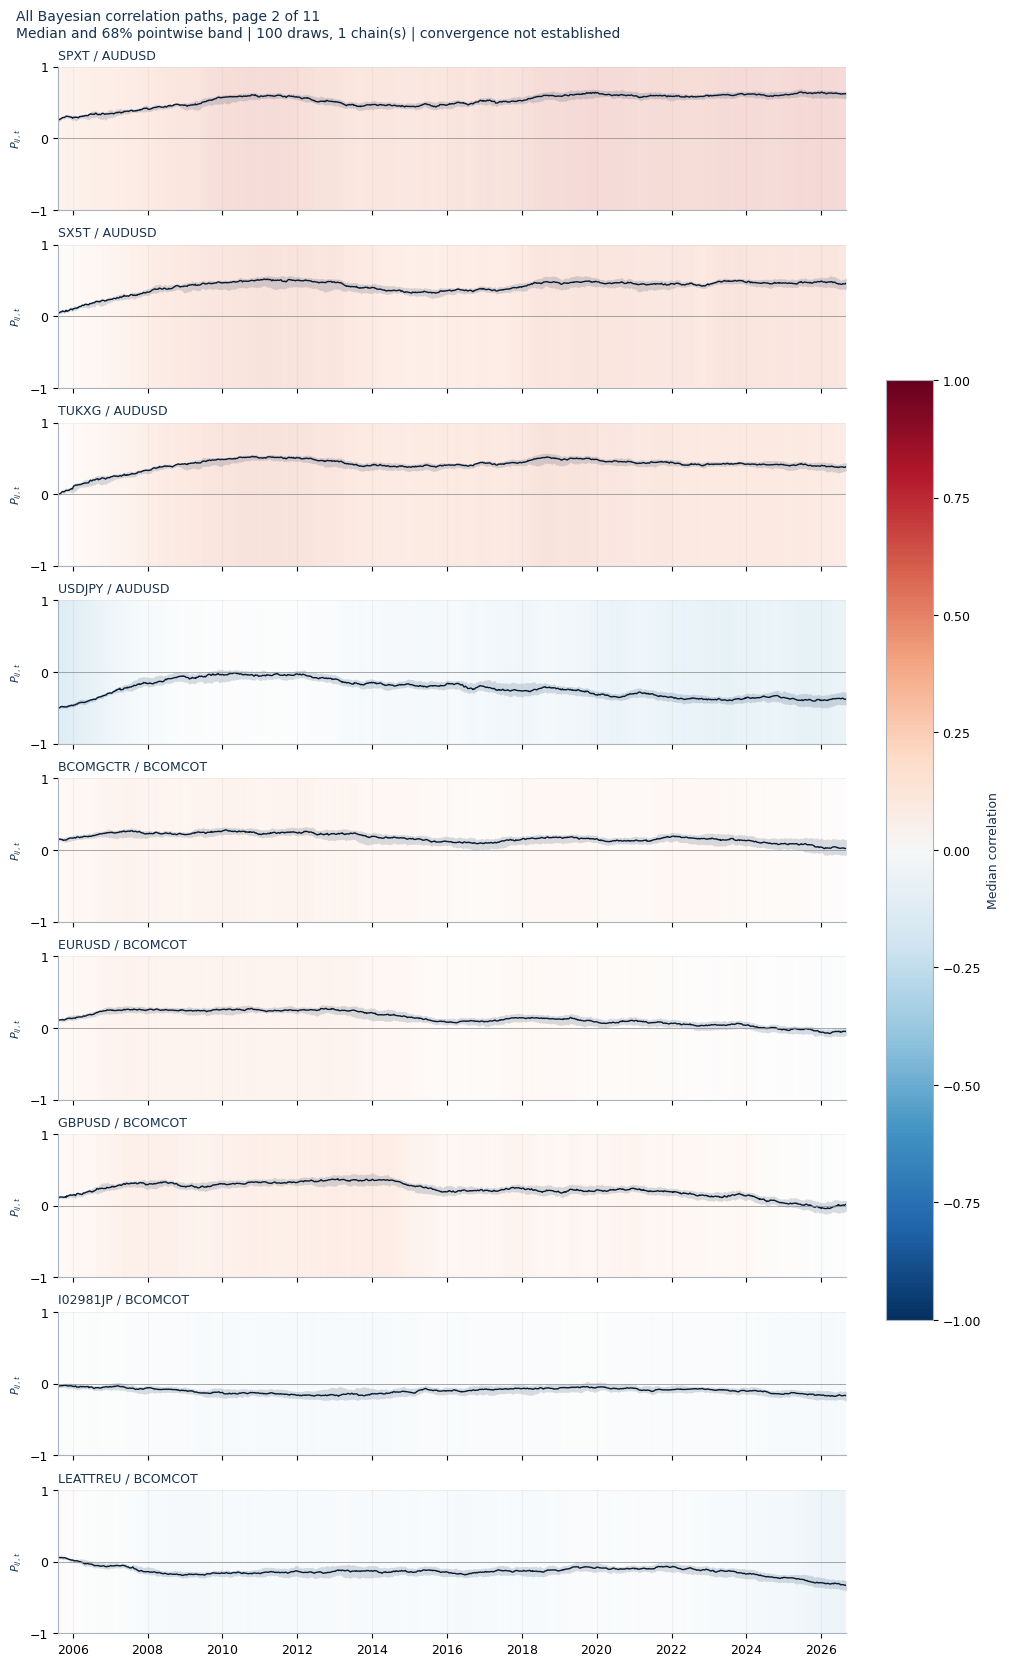

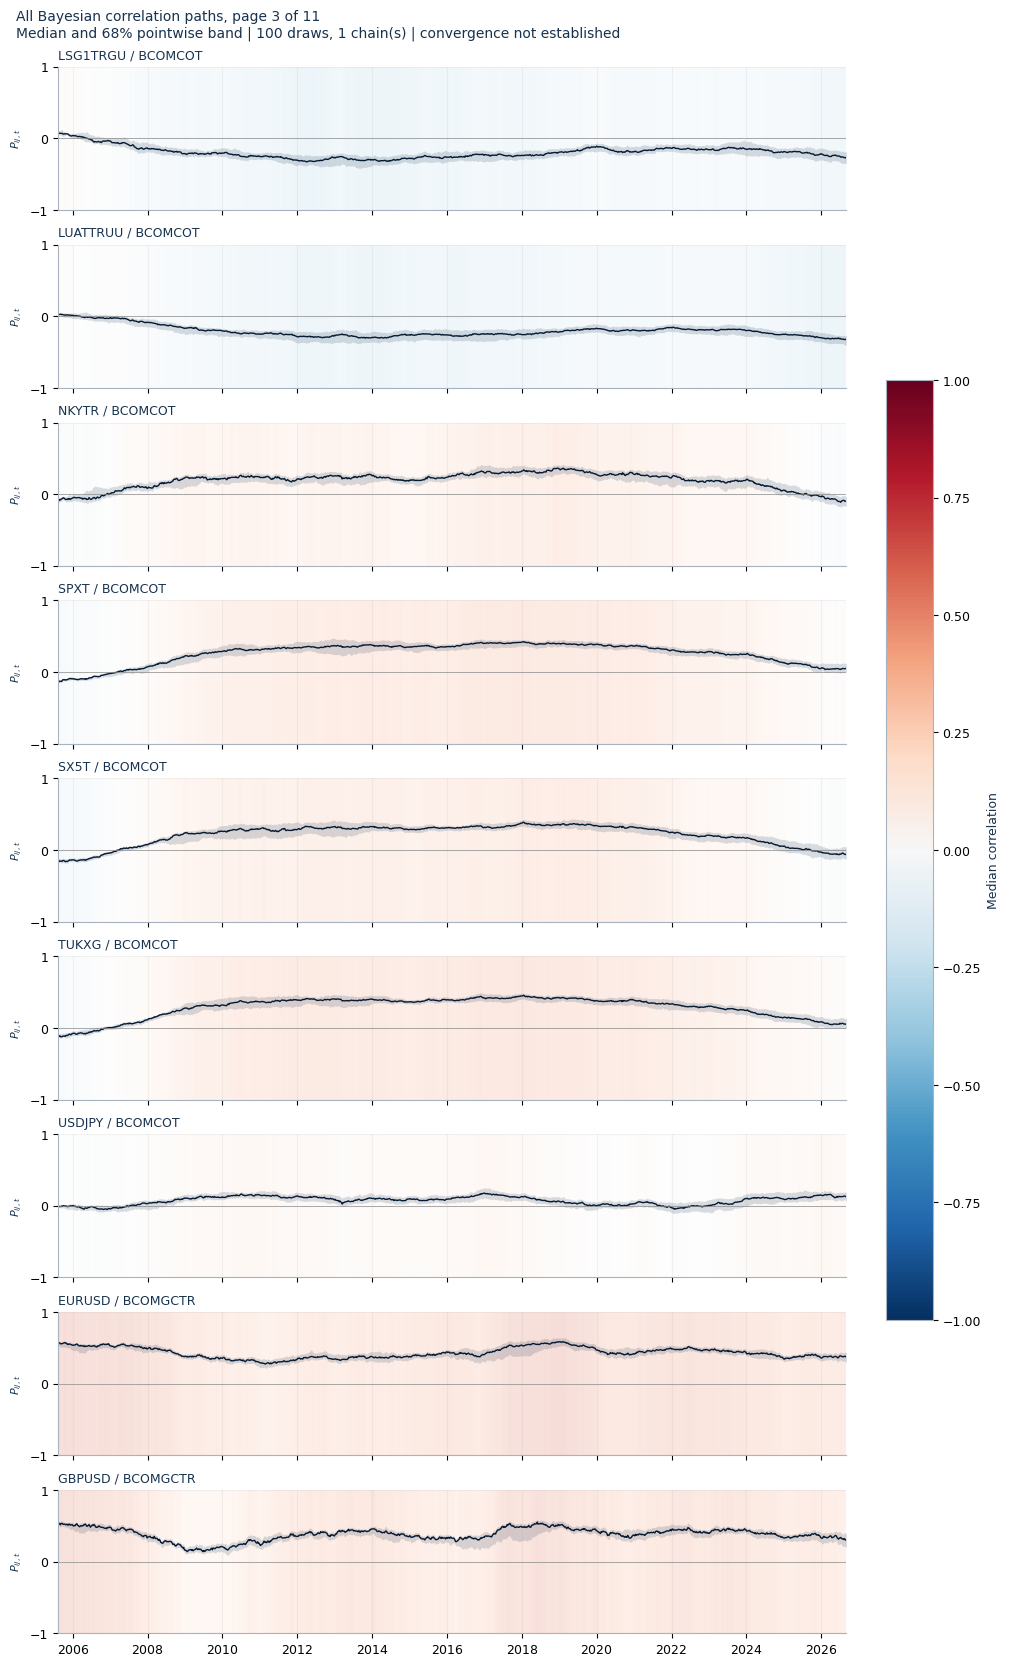

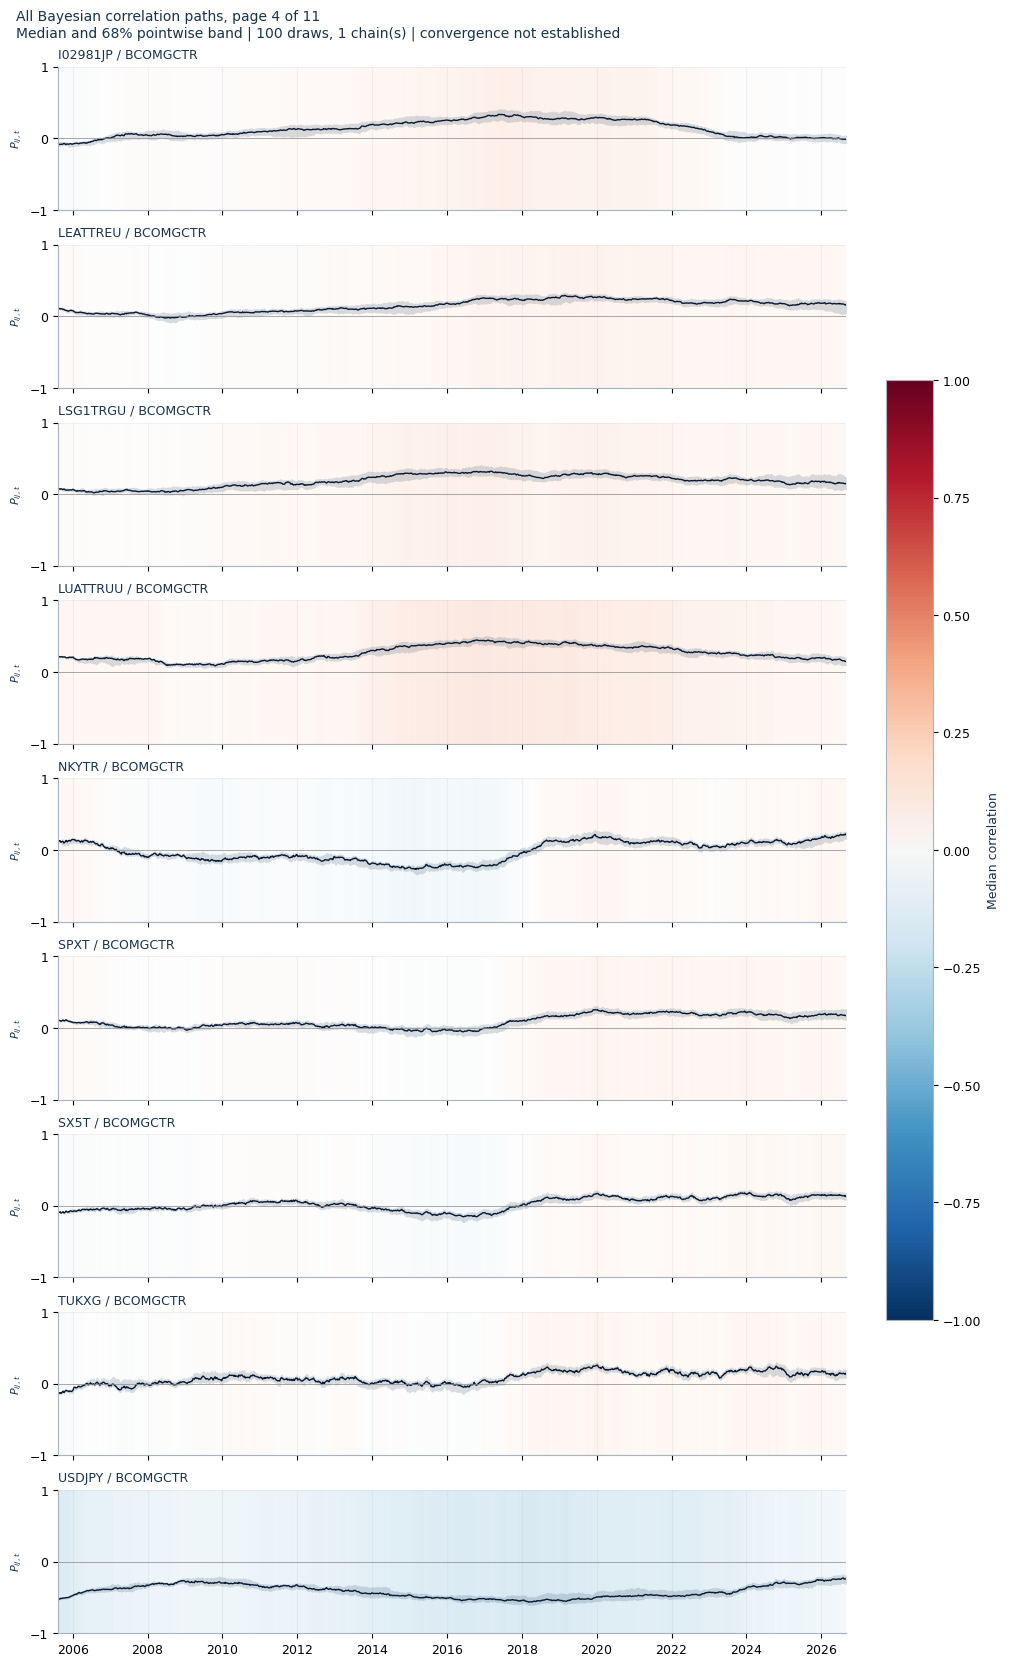

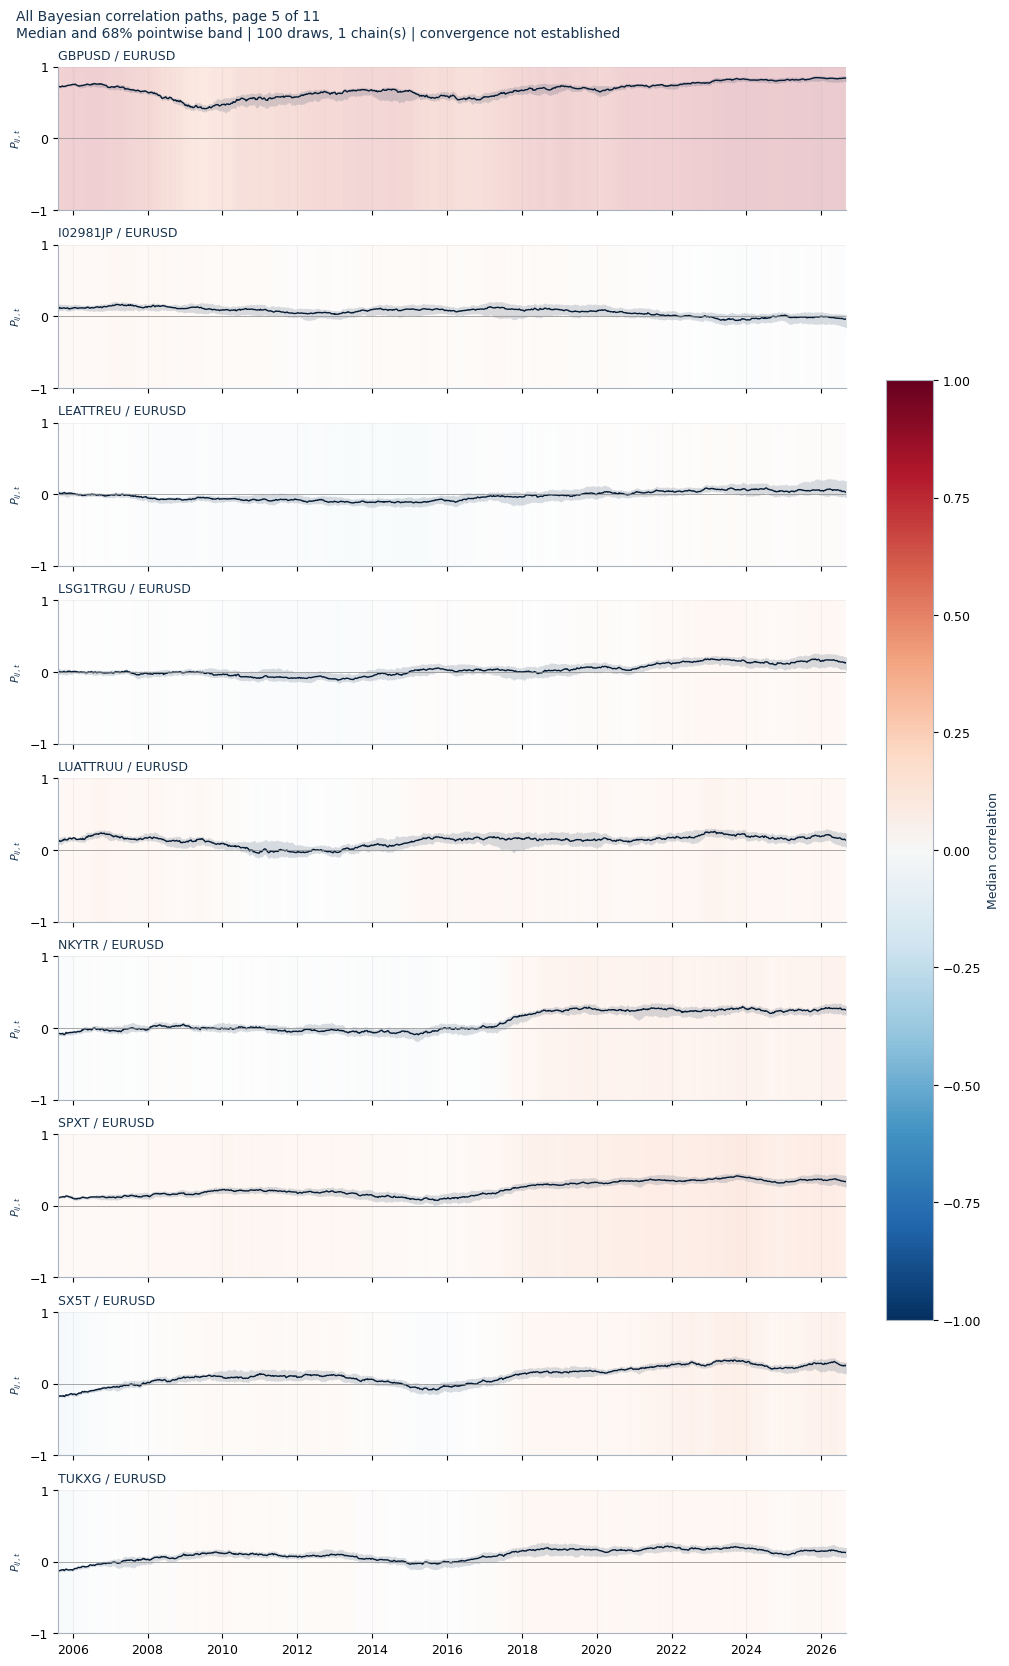

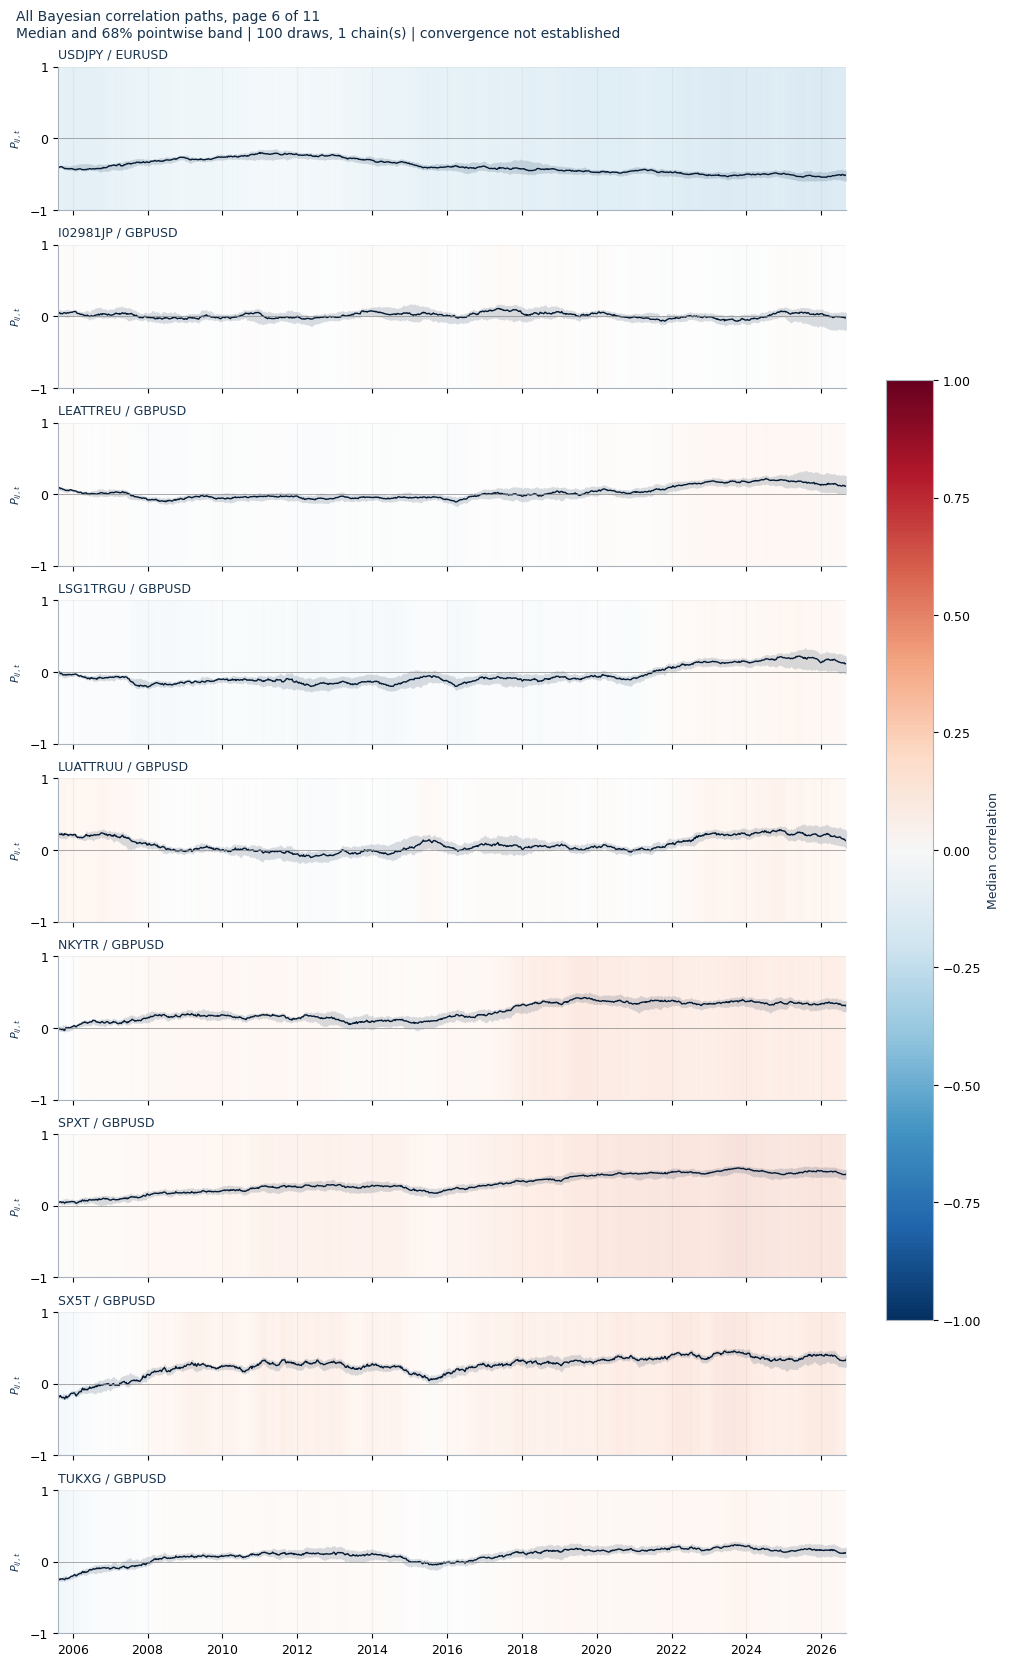

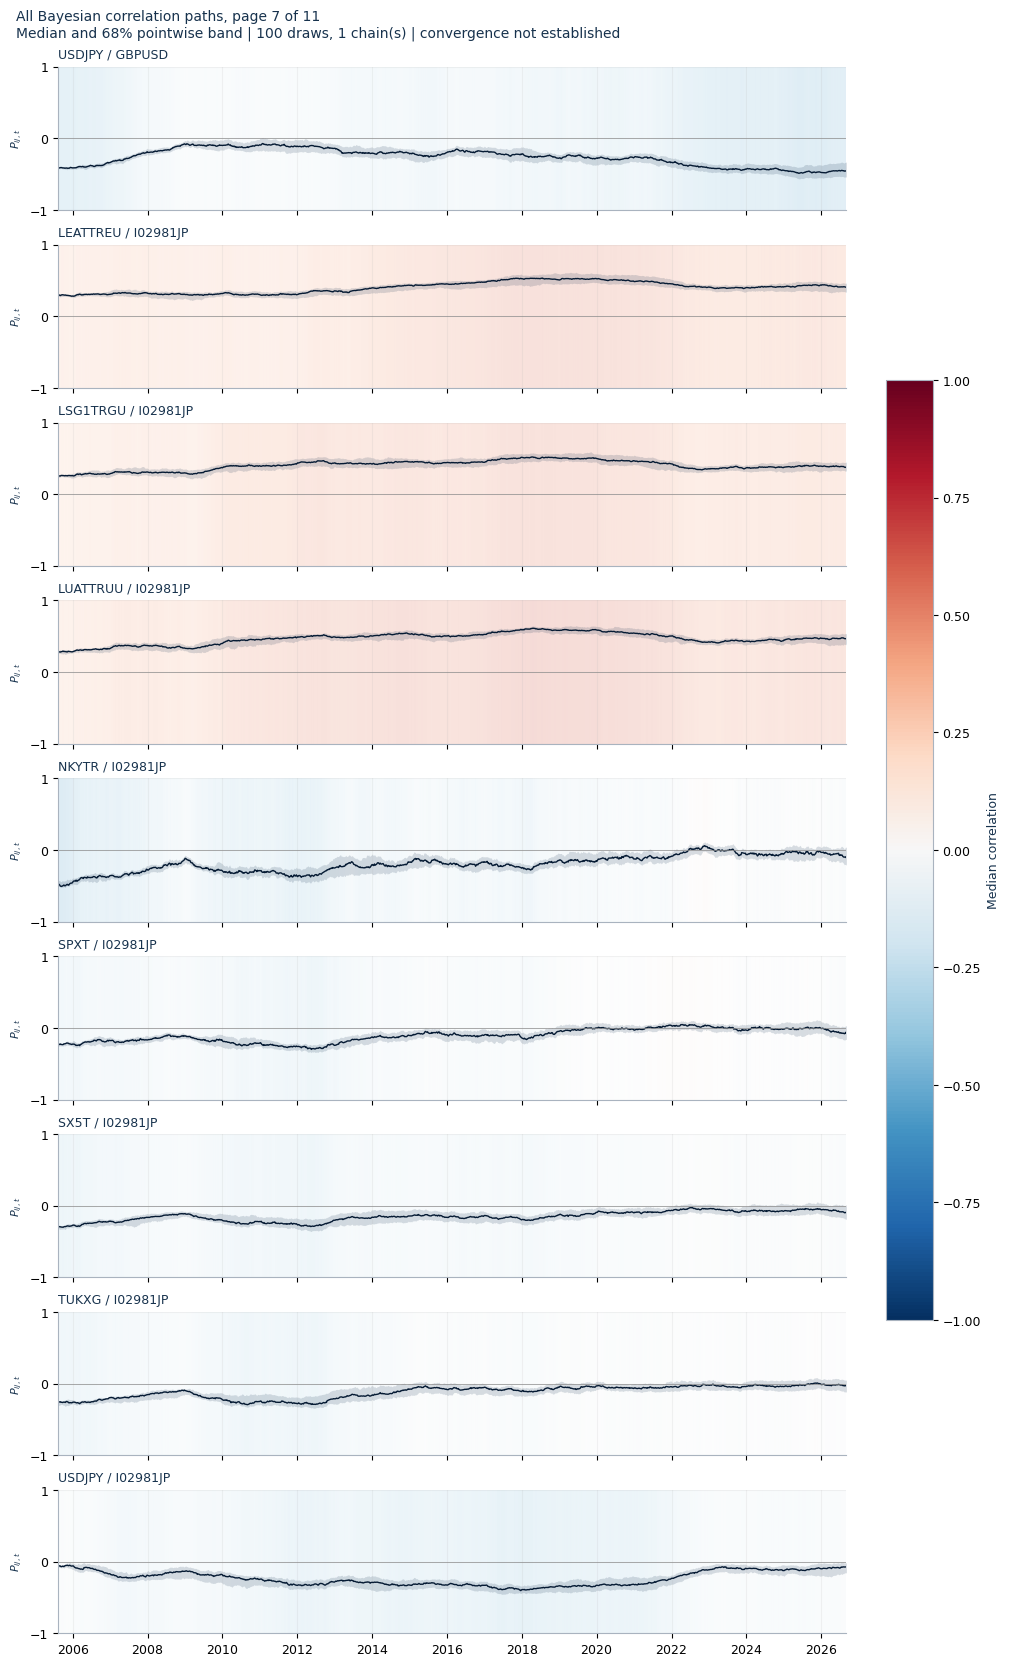

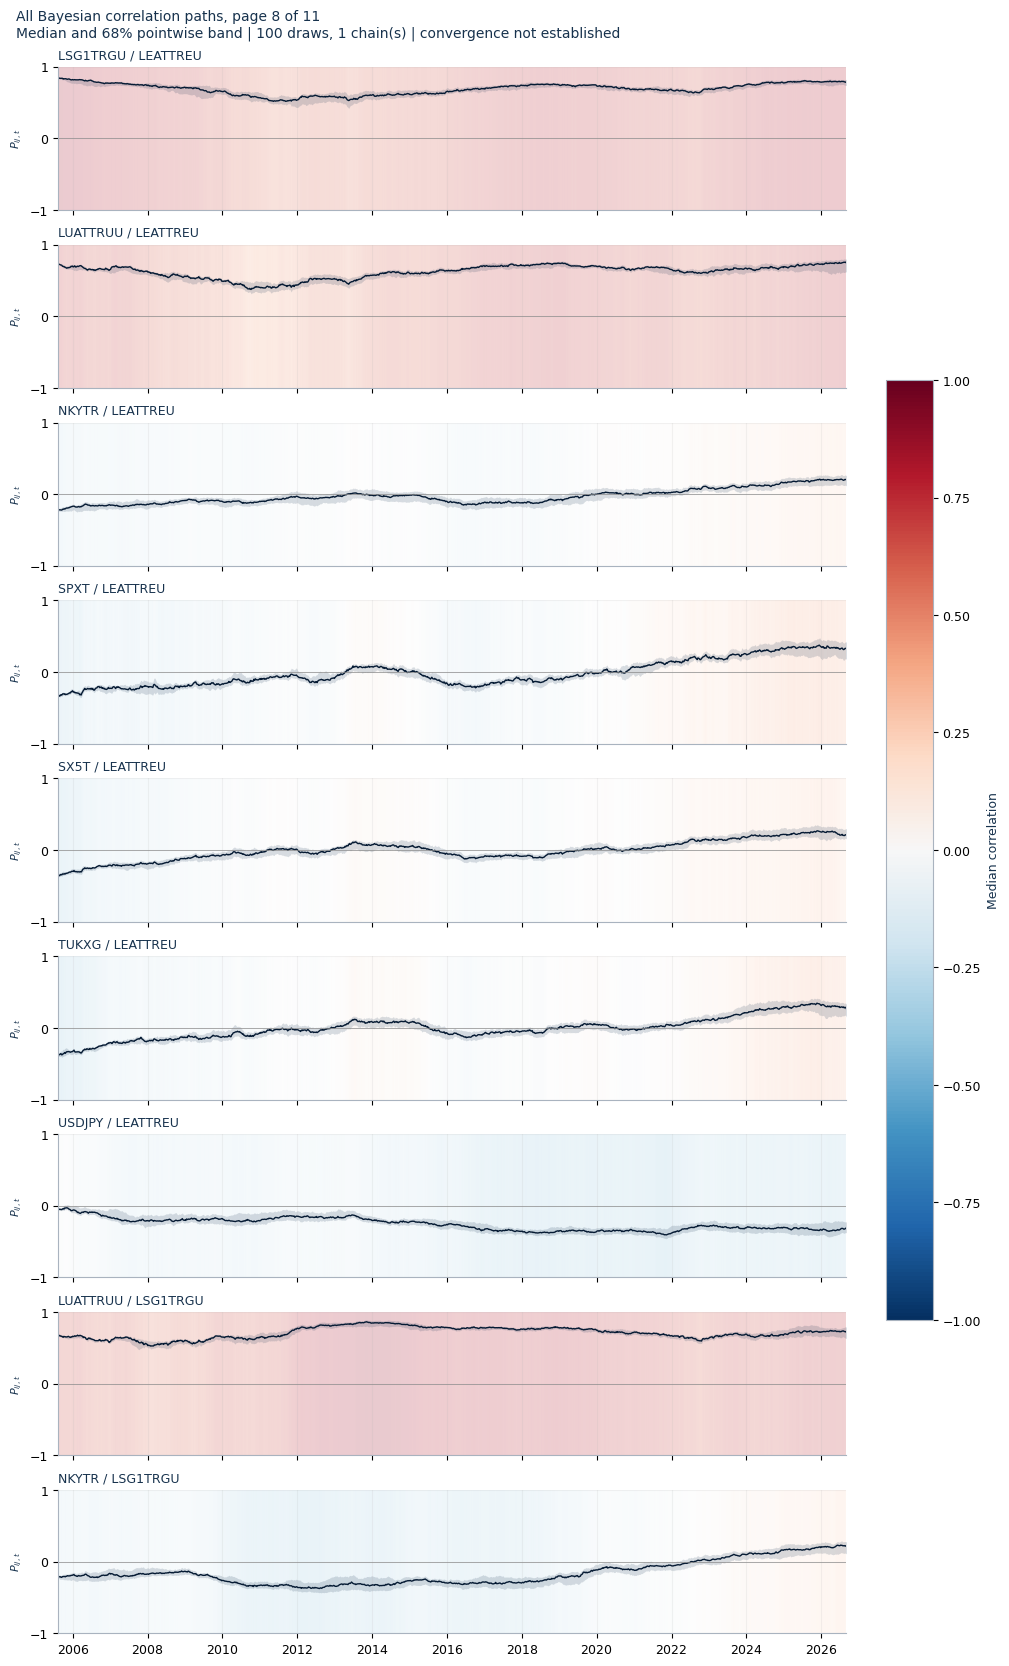

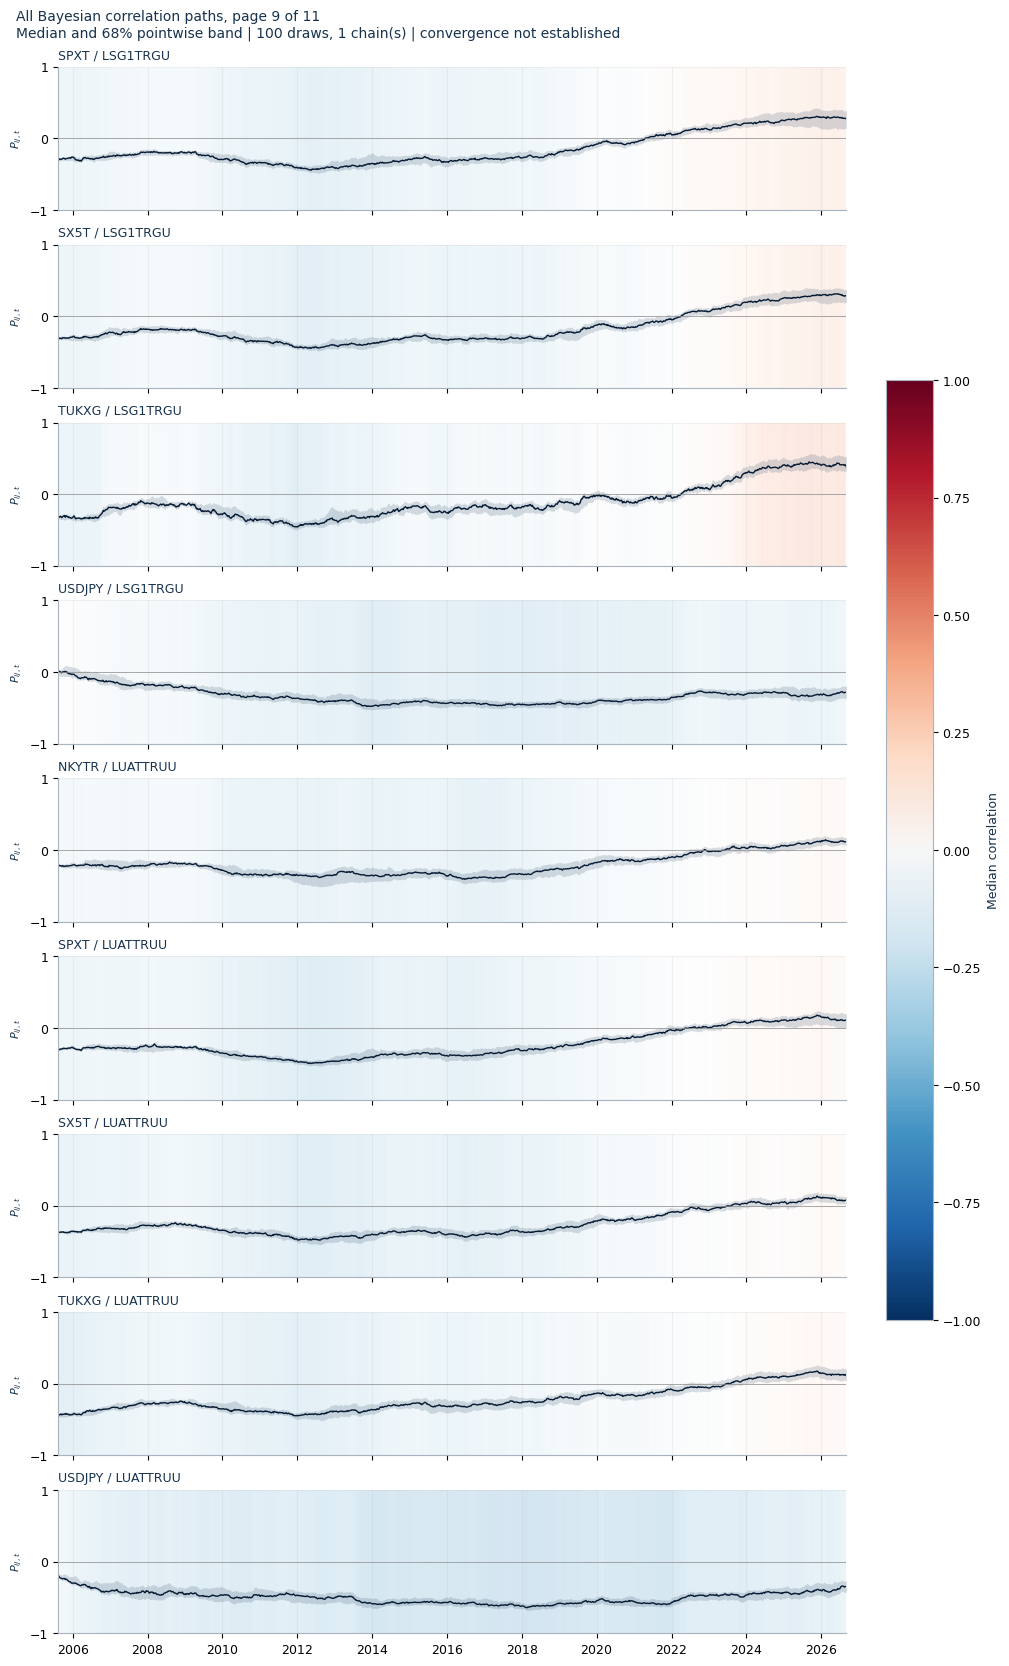

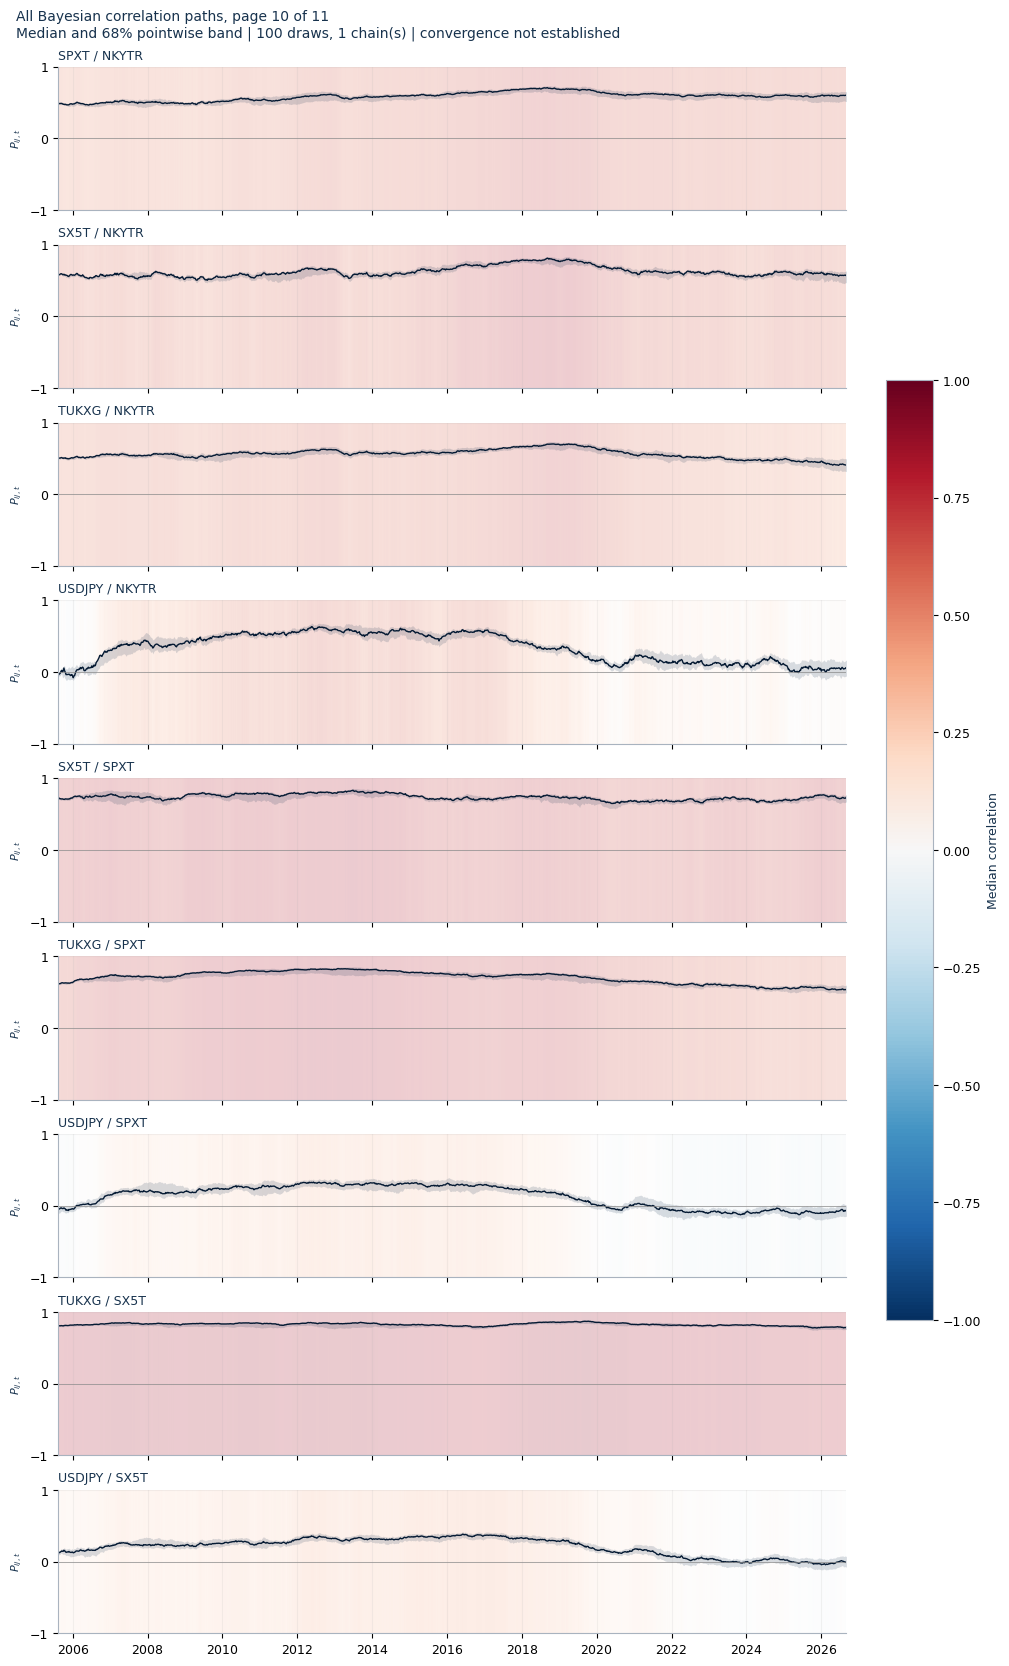

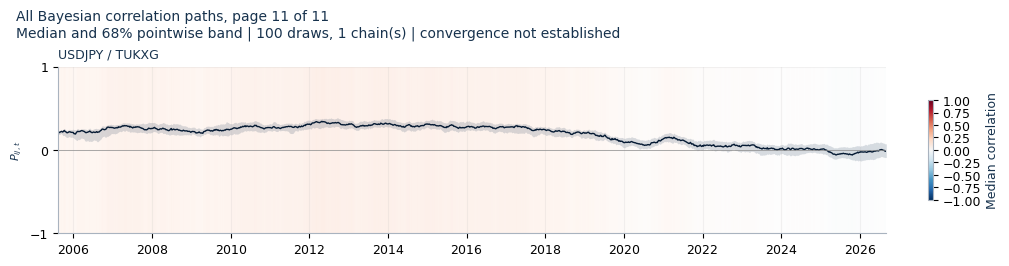

In [39]:
pages = -(-q // 9)
for page in range(pages):
    idx = list(range(page * 9, min(q, page * 9 + 9)))
    bayes_plot(idx, f"All Bayesian correlation paths, page {page + 1} of {pages}", f"bayes_paths_all_{page + 1:02d}.png")

## Appendix C — Exported files and provenance
A manifest of every input's SHA-256 hash, the environment and the check results, so this report can be traced to the exact MATLAB outputs it used.

In [40]:
manifest = {
    "created_at": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "data_dir": str(DATA_DIR), "run_dir": str(RUN_DIR), "source_hash": summary["source_hash"],
    "n_returns": len(returns), "n_pairs": q, "pair_order": expected_pairs,
    "csv_sha256": {p.name: sha256(p) for p in sorted(DATA_DIR.glob("*.csv"))},
    "run_sha256": {name: sha256(RUN_DIR / name) for name in
                   ["pilot_summary.json", "run_manifest.json", "inference_metadata.json", "convergence_diagnostics.json",
                    "posterior_correlation_bands.mat", "figures/bayes_correlation_paths_manifest.json"] if (RUN_DIR / name).is_file()},
    "prior_summary": {"path": str(prior_path), "sha256": sha256(prior_path)},
    "stationarity_method": {"library": f"statsmodels {statsmodels.__version__}", "adf_max_lag": MAX_LAG, "adf_lag_selection": "BIC, common sample",
                            "kpss_bandwidths": list(KPSS_BANDWIDTHS), "dependence_lags": DEPENDENCE_LAGS,
                            "adf_pvalues": "MacKinnon response surfaces (differs slightly from MATLAB tables)"},
    "environment": {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
                    "statsmodels": statsmodels.__version__, "matplotlib": matplotlib.__version__, "h5py": h5py.__version__},
    "checks": pd.DataFrame(CHECKS).to_dict(orient="records"),
}
if SAVE_OUTPUTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "notebook_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
    written = sorted(p.relative_to(OUT_DIR).as_posix() for p in OUT_DIR.rglob("*") if p.is_file())
    show(f"Wrote {len(written)} files to `{OUT_DIR}`:")
    display(pd.DataFrame({"File": written}).style.hide(axis="index"))
else:
    show("`SAVE_OUTPUTS` is off; nothing was written.")

Wrote 38 files to `c:\Users\Jules.Viard\Documents\GitHub\DSC-AC-model\outputs\weekly_research\notebook_report\20260929-183839-212-chain1-w10-r100-thin1`:

File
figures/all_pairs_01.png
figures/all_pairs_02.png
figures/all_pairs_03.png
figures/all_pairs_04.png
figures/all_pairs_05.png
figures/all_pairs_06.png
figures/all_pairs_07.png
figures/all_pairs_08.png
figures/all_pairs_09.png
figures/all_pairs_10.png
